<a href="https://colab.research.google.com/github/renu623/Ytube-nwp/blob/main/bankruptcy_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df = pd.read_csv('/content/archive (13).zip')

In [ ]:
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
# failed_companies = df[df['status_label']=='failed']
# alive_companies = df[df['status_label']=='alive'].drop_duplicates(subset='campany_name')

In [ ]:
df.drop(columns='company_name', inplace=True)

In [ ]:
df.rename(columns={'X1': 'Current assets', 'X2': 'Cost of goods sold', 'X3': 'Depreciation and amortization' , 'X4' : 'EBITDA' ,  'X5' : 'Inventory', 'X6' : 'Net Income' , 'X7' : 'Total Receivables' , 'X8' : 'Market value' ,'X9' : 'Net sales' , 'X10' : 'Total assets', 'X11' : 'Total Long-term debt' , 'X12': 'EBIT' , 'X13' : 'Gross Profit' ,'X14': 'Total Current Liabilities', 'X15' : 'Retained Earnings' ,'X16' : 'Total Revenue', 'X17': 'Total Liabilities' ,'X18' : 'Total Operating Expenses' }, inplace=True)

In [ ]:

df['Net Profit Margin']=df['Net Income']/df['Total Revenue']
df['Gross Profit Margin']= df['Gross Profit']/df['Net sales']
df['ROA']=df['Net Income']/df['Total assets']
df['ROS']=df['Net Income']/df['Net sales']
df['Current Ratio']=df['Current assets']/df['Total Current Liabilities']
df['Quick Ratio']=(df['Current assets']-df['Inventory'])/df['Total Current Liabilities']
df['Debt to asset ratio']=df['Total Liabilities']/df['Total assets']

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(sampling_strategy='minority', random_state=42)
oversampled_X, oversampled_Y = sm.fit_resample(df.drop('status_label', axis=1, inplace = False), df['status_label'])
smote_df = pd.concat([pd.DataFrame(oversampled_Y),pd.DataFrame(oversampled_X)],axis=1)

In [ ]:
smote_df.head()

,status_label,year,Current assets,Cost of goods sold,Depreciation and amortization,EBITDA,Inventory,Net Income,Total Receivables,Market value,...,Total Revenue,Total Liabilities,Total Operating Expenses,Net Profit Margin,Gross Profit Margin,ROA,ROS,Current Ratio,Quick Ratio,Debt to asset ratio
0,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,...,1024.333,401.483,935.302,0.034328,0.186683,0.047454,0.034328,3.120983,1.069792,0.541814
1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,...,874.255,361.642,809.888,0.021196,0.183521,0.026403,0.021196,3.874697,1.317995,0.515267
2,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,...,638.721,399.964,611.514,-0.092277,0.175732,-0.082989,-0.092277,2.902063,0.997368,0.563172
3,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,...,606.337,391.633,575.592,-0.020467,0.180741,-0.018074,-0.020467,1.947253,0.670308,0.570377
4,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,...,651.958,407.608,604.467,0.005375,0.197338,0.004940,0.005375,3.292707,1.409093,0.574669


<Axes: >

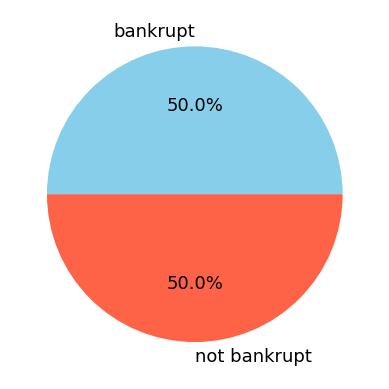

In [ ]:
smote_df.groupby('status_label').size().plot(kind='pie',
                                       autopct='%.1f%%',
                                       fontsize=13,
                                                labels=['bankrupt','not bankrupt'],
                                       colors=['skyblue', 'tomato'])

In [ ]:
status_map = {"failed": 0, "alive": 1}
smote_df['status_label_Encoded'] = smote_df['status_label'].map(status_map)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load your dataset
df
X = smote_df.drop(columns=["status_label", "status_label_Encoded"])
y = smote_df["status_label_Encoded"].values

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


**XG Boost CNN**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Define CNN Feature Extractor
class CNNFeatureExtractor(nn.Module):
    def __init__(self, input_channels):
        super(CNNFeatureExtractor, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.3)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        return self.flatten(x)

#Full CNN + Classifier Model with Dynamic Flattening
class CNNWithHead(nn.Module):
    def __init__(self, input_channels, input_features, output_size):
        super(CNNWithHead, self).__init__()
        self.feature_extractor = CNNFeatureExtractor(input_channels)

        # Dynamically get the flattened size after CNN
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_features)
            flattened_output = self.feature_extractor(dummy_input)
            flattened_size = flattened_output.shape[1]

        self.classifier = nn.Linear(flattened_size, output_size)

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

#Prepare your data
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (batch, channels=1, features)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

#Dataset and Loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Model, loss, optimizer
input_channels = 1
input_features = X_train.shape[1]
output_classes = len(np.unique(y_train))

model = CNNWithHead(input_channels, input_features, output_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
for epoch in range(10):  # Increase if needed
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")



Epoch 1, Loss: 1125.0551
Epoch 2, Loss: 1078.1158
Epoch 3, Loss: 1064.3982
Epoch 4, Loss: 1050.5586
Epoch 5, Loss: 1043.5234
Epoch 6, Loss: 1039.4983
Epoch 7, Loss: 1034.9370
Epoch 8, Loss: 1026.9117
Epoch 9, Loss: 1023.7120
Epoch 10, Loss: 1020.9119


In [ ]:
# import torch
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# # Ensure model is on the same device as input tensors
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval()

# # Move input tensors to device
# X_train_tensor = X_train_tensor.to(device)
# X_test_tensor = X_test_tensor.to(device)

# # Step 1: Extract CNN features
# with torch.no_grad():
#     train_features = model.feature_extractor(X_train_tensor).cpu().numpy()
#     test_features = model.feature_extractor(X_test_tensor).cpu().numpy()

# # Step 2: Train SVM
# svm = SVC(kernel='rbf', C=1.0, gamma='scale')
# svm.fit(train_features, y_train)

# # Step 3: Evaluate
# # y_pred = svm.predict(test_features
# accuracy = accuracy_score(y_test, y_pred)

# print("SVM on CNN Features:")
# print(classification_report(y_test, y_pred))
# print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
# print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")


In [ ]:
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# # # ==== Simulate Data (Replace this with your real dataset) ====
# # np.random.seed(0)
# # X = np.random.rand(1000, 26)  # 1000 samples, 26 features
# # y = np.random.randint(0, 2, size=1000)  # Binary classification

# # # ==== Preprocess ====
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)

# # X_train, X_test, y_train, y_test = train_test_split(
# #     X_scaled, y, test_size=0.2, random_state=42
# # )

# # Convert to PyTorch tensors with correct shape: [batch, channels, features]
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.svm import LinearSVC
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# # ==== Simulate Data (Replace this with your real dataset) ====
# np.random.seed(0)
# X = np.random.rand(1000, 26)  # 1000 samples, 26 features
# y = np.random.randint(0, 2, size=1000)  # Binary classification

# # ==== Preprocess ====
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42
# )

# # Convert to PyTorch tensors with correct shape: [batch, channels, features]
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

# # Create DataLoaders
# batch_size = 64
# train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size)
# test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=batch_size)

# # ==== Define CNN Model ====
# class SimpleCNN(nn.Module):
#     def __init__(self):
#         super(SimpleCNN, self).__init__()
#         self.feature_extractor = nn.Sequential(
#             nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3),
#             nn.ReLU(),
#             nn.Conv1d(16, 32, kernel_size=3),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool1d(1),  # Output shape: [batch, 32, 1]
#         )

#     def forward(self, x):
#         features = self.feature_extractor(x)
#         return features.view(x.size(0), -1)  # Flatten for classification (if needed)

# model = SimpleCNN()

# # ==== Feature Extraction ====
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device)
# model.eval()

# def extract_features(model, dataloader):
#     features = []
#     with torch.no_grad():
#         for (batch,) in dataloader:
#             batch = batch.to(device)
#             output = model.feature_extractor(batch).cpu().squeeze(-1)
#             features.append(output)
#     return torch.cat(features).numpy()

# train_features = extract_features(model, train_loader)
# test_features = extract_features(model, test_loader)

# # ==== Train SVM on CNN Features ====
# svm = LinearSVC(max_iter=5000)
# svm.fit(train_features, y_train)

# # ==== Evaluate ====
# y_pred = svm.predict(test_features)
# accuracy = accuracy_score(y_test, y_pred)

# print("CNN + SVM Results:")
# print("Accuracy:", accuracy)
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))


CNN + SVM Results:
Accuracy: 0.6195678067041007
Confusion Matrix:
 [[11335  3462]
 [ 7717  6871]]
Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.77      0.67     14797
           1       0.66      0.47      0.55     14588

    accuracy                           0.62     29385
   macro avg       0.63      0.62      0.61     29385
weighted avg       0.63      0.62      0.61     29385



In [ ]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score , classification_report, confusion_matrix


# # Step 1: Extract CNN features from training and test data
# model.eval()  # set CNN to evaluation mode

# with torch.no_grad():
#     cnn_train_features = model.feature_extractor(X_train_tensor).numpy()
#     cnn_test_features = model.feature_extractor(X_test_tensor).numpy()

# # Step 2: Train XGBoost on these features
# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# xgb_model.fit(cnn_train_features, y_train)

# # Step 3: Evaluate XGBoost model
# y_pred_xgb = xgb_model.predict(cnn_test_features)
# accuracy = accuracy_score(y_test, y_pred_xgb)
# print("XGBoost on CNN Features:")
# print(classification_report(y_test, y_pred_xgb))
# print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
# print(f" XGBoost on CNN Features Accuracy: {accuracy * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:39:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost on CNN Features:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     14797
           1       0.93      0.86      0.90     14588

    accuracy                           0.90     29385
   macro avg       0.90      0.90      0.90     29385
weighted avg       0.90      0.90      0.90     29385

Accuracy: 0.9007
 XGBoost on CNN Features Accuracy: 90.07%


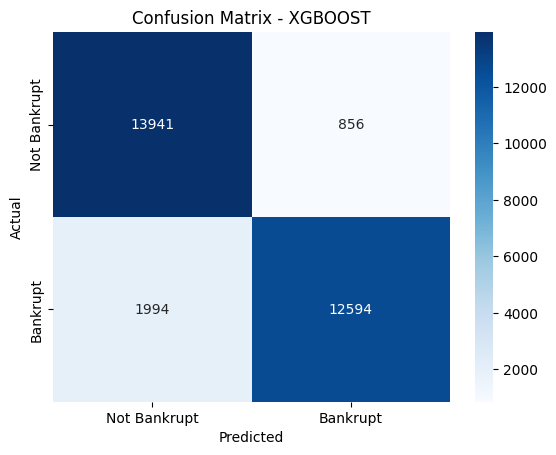

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# conf_matrix = confusion_matrix(y_test, y_pred_xgb)
# sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
# plt.title("Confusion Matrix - XGBOOST")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# # plt.show()

In [ ]:

# from xgboost import XGBClassifier
# from sklearn.metrics import classification_report, accuracy_score

# xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# xgb_model.fit(features_train, y_train)
# y_pred_xgb = xgb_model.predict(features_test)

# # Print metrics
# print("XGBoost on CNN Features:")
# print(classification_report(y_test, y_pred_xgb))
# print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:30:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


📊 XGBoost on CNN Features:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89     14797
           1       0.92      0.84      0.88     14588

    accuracy                           0.88     29385
   macro avg       0.89      0.88      0.88     29385
weighted avg       0.89      0.88      0.88     29385

✅ Accuracy: 0.8841


In [ ]:
# import lime
# import lime.lime_tabular

# # Lime on XGBoost + CNN features
# explainer = lime.lime_tabular.LimeTabularExplainer(
#     training_data=features_train,
#     feature_names=[f'feat_{i}' for i in range(features_train.shape[1])],
#     class_names=['Not Bankrupt', 'Bankrupt'],
#     mode='classification'
# )

# # Pick an instance to explain
# idx = 1
# exp = explainer.explain_instance(features_test[idx], xgb_model.predict_proba, num_features=10)
# exp.show_in_notebook(show_table=True, show_all=False)


In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1fb590de2b4134a8694e1d9c6db70008d453e4366d776485bdf919b647fb359c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


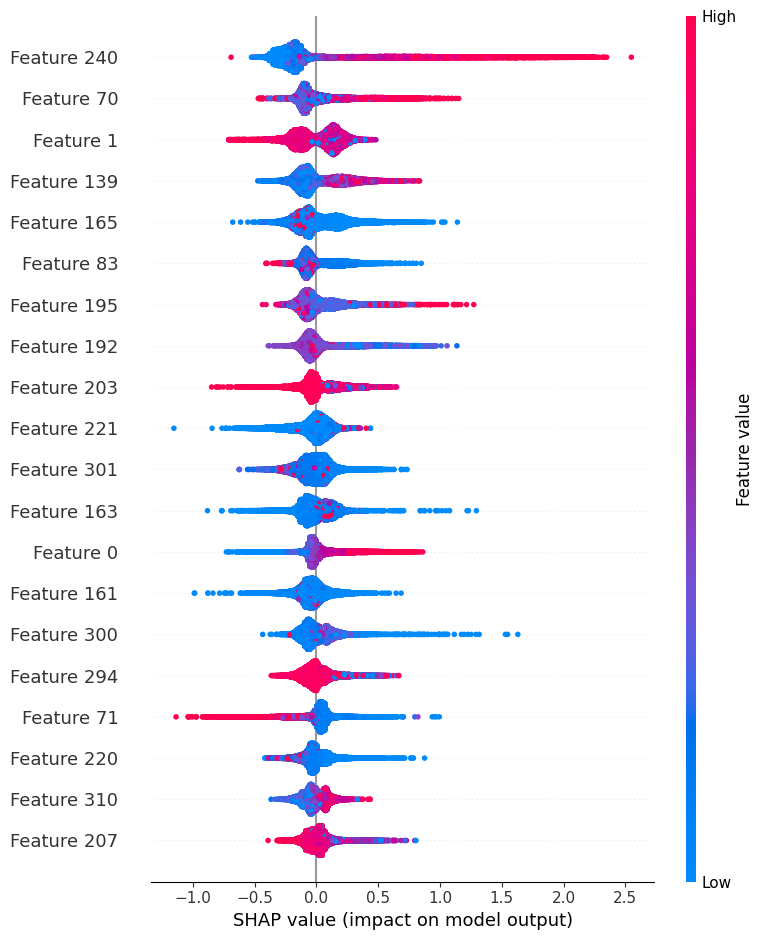

In [ ]:
# import shap
# import matplotlib.pyplot as plt

# # Create TreeExplainer for XGBoost
# explainer = shap.TreeExplainer(xgb_model)

# # Calculate SHAP values for test data
# shap_values = explainer.shap_values(features_test)

# #  Summary plot (global feature importance)
# shap.summary_plot(shap_values, features_test)

# **ADA BOOST CNN**

 AdaBoost on CNN Features Accuracy: 70.74%

 Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72     14797
           1       0.73      0.65      0.69     14588

    accuracy                           0.71     29385
   macro avg       0.71      0.71      0.71     29385
weighted avg       0.71      0.71      0.71     29385



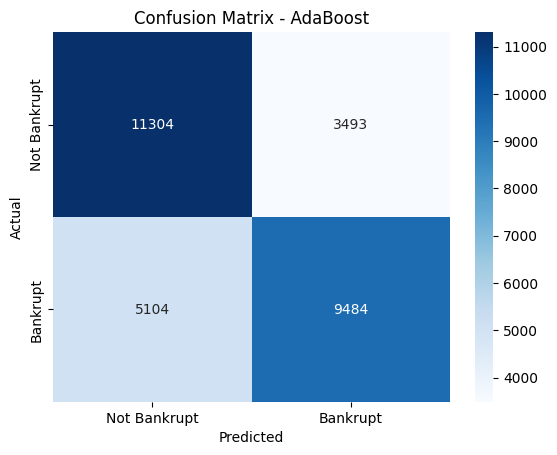

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set CNN to evaluation mode
model.eval()

#  Extract features from CNN
with torch.no_grad():
    cnn_train_features = model.feature_extractor(X_train_tensor).numpy()
    cnn_test_features = model.feature_extractor(X_test_tensor).numpy()

#  Train AdaBoost classifier on CNN features
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(cnn_train_features, y_train)

# Predict on test data
y_pred_ada = ada_model.predict(cnn_test_features)

# Accuracy
accuracy = accuracy_score(y_test, y_pred_ada)
print(f" AdaBoost on CNN Features Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred_ada))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
y_pred_ada_cnn = y_pred_ada

Weighted Precision: 0.7025
Weighted Recall: 0.7024
Weighted F1 Score: 0.7023
AUC Score: 0.7792


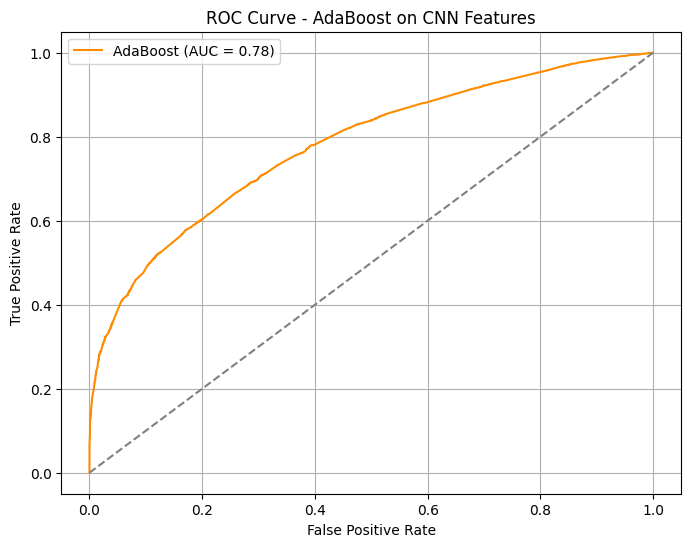

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, roc_curve

# === Overall metrics ===
precision = precision_score(y_test, y_pred_ada, average='weighted')
recall = recall_score(y_test, y_pred_ada, average='weighted')
f1 = f1_score(y_test, y_pred_ada, average='weighted')

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1 Score: {f1:.4f}")

# === AUC Score and ROC Curve ===
# Get predicted probabilities for positive class
y_scores = ada_model.predict_proba(cnn_test_features)[:, 1]

# Compute ROC curve and AUC
fpr_ada_cnn, tpr_ada_cnn, _ = roc_curve(y_test, y_scores)
auc_score_ada_cnn = roc_auc_score(y_test, y_scores)

print(f"AUC Score: {auc_score_ada_cnn:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f"AdaBoost (AUC = {auc_score_ada_cnn:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost on CNN Features')
plt.legend()
plt.grid(True)
plt.show()


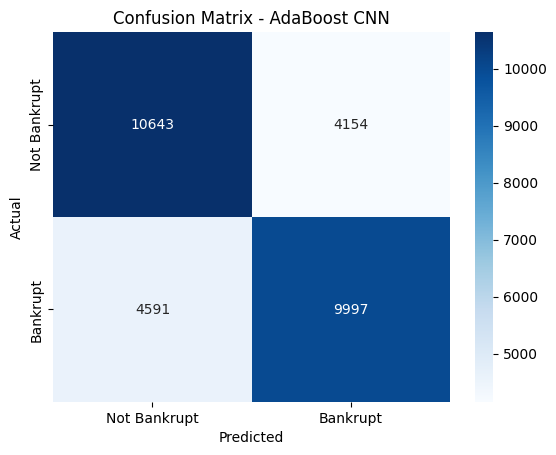

In [ ]:
conf_matrix_ada_cnn = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - AdaBoost CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ada boosting ml

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score



# Define base estimator: shallow tree for speed
base_estimator = DecisionTreeClassifier(max_depth=1)

# Define AdaBoost model
ada = AdaBoostClassifier(estimator=base_estimator, random_state=42)

# Lightweight parameter grid for fast execution
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}

# Grid search with 3-fold CV for speed
grid_search = GridSearchCV(estimator=ada, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found:  {'learning_rate': 1.0, 'n_estimators': 100}
Accuracy on test data: 0.6906925302024842
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14797
           1       0.70      0.65      0.68     14588

    accuracy                           0.69     29385
   macro avg       0.69      0.69      0.69     29385
weighted avg       0.69      0.69      0.69     29385



In [ ]:
y_pred_ada_ml = grid_search.best_estimator_.predict(X_test)

Best parameters found:  {'learning_rate': 1.0, 'n_estimators': 100}
Accuracy on test data: 0.6906925302024842
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14797
           1       0.70      0.65      0.68     14588

    accuracy                           0.69     29385
   macro avg       0.69      0.69      0.69     29385
weighted avg       0.69      0.69      0.69     29385

Overall Precision: 0.7029
Overall Recall: 0.6530
Overall F1 Score: 0.6770
AUC: 0.7606


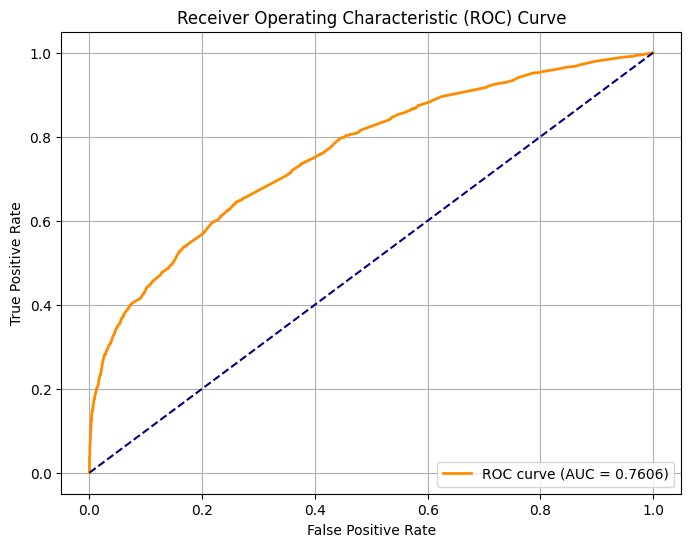

In [ ]:
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_curve, auc, precision_score,
    recall_score, f1_score
)

best_model = grid_search.best_estimator_
print("Best parameters found: ", grid_search.best_params_)
y_proba = best_model.predict_proba(X_test)[:, 1]  # For ROC curve and AUC

# Accuracy
print("Accuracy on test data:", accuracy_score(y_test, y_pred))

# Classification report
print("Classification report:\n", classification_report(y_test, y_pred))

# General evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")
print(f"Overall F1 Score: {f1:.4f}")

# ROC curve
fpr_ada, tpr_ada, thresholds = roc_curve(y_test, y_proba)
roc_auc_ada = auc(fpr_ada, tpr_ada)
print(f"AUC: {roc_auc_ada:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_ada:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()


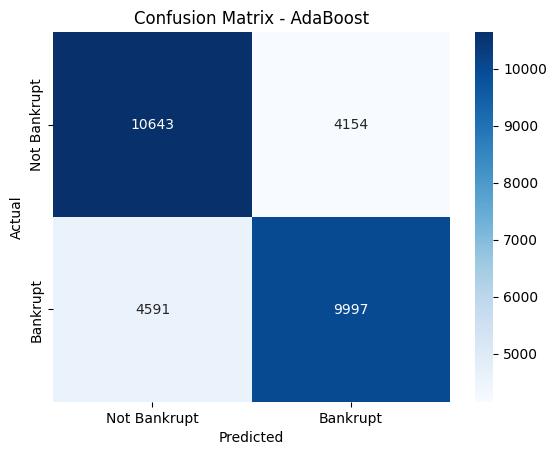

In [ ]:
conf_matrix_ada = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Set CNN to evaluation mode
# model.eval()

# # Extract features from CNN
# with torch.no_grad():
#     cnn_train_features = model.feature_extractor(X_train_tensor).numpy()
#     cnn_test_features = model.feature_extractor(X_test_tensor).numpy()

# # Train AdaBoost classifier on CNN features
# ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
# ada_model.fit(cnn_train_features, y_train)
# y_pred_ada = ada_model.predict(cnn_test_features)

# # Accuracy and classification report for AdaBoost
# print(f"AdaBoost on CNN Features Accuracy: {accuracy_score(y_test, y_pred_ada) * 100:.2f}%")
# print("\nAdaBoost Classification Report:")
# print(classification_report(y_test, y_pred_ada))

# # Confusion Matrix for AdaBoost
# plt.figure(figsize=(6, 4))
# sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt="d", cmap="Blues",
#             xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
# plt.title("Confusion Matrix - AdaBoost")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # ---- Gradient Boosting Classifier ---- #
# gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
# gb_model.fit(cnn_train_features, y_train)
# y_pred_gb = gb_model.predict(cnn_test_features)

# # Accuracy and classification report for Gradient Boosting
# print(f"\nGradient Boosting on CNN Features Accuracy: {accuracy_score(y_test, y_pred_gb) * 100:.2f}%")
# print("\nGradient Boosting Classification Report:")
# print(classification_report(y_test, y_pred_gb))

# # Confusion Matrix for Gradient Boosting
# plt.figure(figsize=(6, 4))
# sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt="d", cmap="Greens",
#             xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
# plt.title("Confusion Matrix - Gradient Boosting")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()


In [ ]:
# import lime
# import lime.lime_tabular

# # Use scaled original features (not CNN features)
# explainer = lime.lime_tabular.LimeTabularExplainer(
#     training_data=X_train,
#     feature_names=smote_df.drop("status_label", axis=1).columns.tolist(),
#     class_names=['Not Bankrupt', 'Bankrupt'],
#     mode='classification'
# )


In [ ]:
# explainer = lime.lime_tabular.LimeTabularExplainer(
#     training_data=features_train,
#     feature_names=[f'cnn_feat_{i}' for i in range(features_train.shape[1])],
#     class_names=['Not Bankrupt', 'Bankrupt'],
#     mode='classification',
#     discretize_continuous=True,  # or False
#     categorical_features=[]      # Add this line to prevent the KeyError
# )

# idx = 1
# idx = 1
# print("Feature shape for LIME:", features_test[idx].shape)

# exp = explainer.explain_instance(
#     features_test[idx],
#     xgb_model.predict_proba,
#     num_features=10
# )
# exp.show_in_notebook(show_table=True, show_all=False)


Feature shape for LIME: (320,)


# **Random forest**

3. Random Forest +CNN

In [ ]:
class CNNWithHead(nn.Module):
    def __init__(self, base_cnn, sample_input_shape, output_size):
        super(CNNWithHead, self).__init__()
        self.base = base_cnn

        # Get flattened size by passing dummy input through base CNN
        with torch.no_grad():
            dummy_input = torch.zeros(1, *sample_input_shape)  # shape: (1, channels, features)
            dummy_output = self.base(dummy_input)
            flattened_size = dummy_output.shape[1]

        self.fc = nn.Linear(flattened_size, output_size)

    def forward(self, x):
        x = self.base(x)
        return self.fc(x)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Define CNN Feature Extractor
class CNNFeatureExtractor(nn.Module):
    def __init__(self, input_channels):
        super(CNNFeatureExtractor, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 32, kernel_size=3)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout = nn.Dropout(0.3)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        return self.flatten(x)

#Full CNN + Classifier Model with Dynamic Flattening
class CNNWithHead(nn.Module):
    def __init__(self, input_channels, input_features, output_size):
        super(CNNWithHead, self).__init__()
        self.feature_extractor = CNNFeatureExtractor(input_channels)

        # Dynamically get the flattened size after CNN
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, input_features)
            flattened_output = self.feature_extractor(dummy_input)
            flattened_size = flattened_output.shape[1]

        self.classifier = nn.Linear(flattened_size, output_size)

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)

#Prepare your data
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # (batch, channels=1, features)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

#Dataset and Loader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Model, loss, optimizer
input_channels = 1
input_features = X_train.shape[1]
output_classes = len(np.unique(y_train))

model = CNNWithHead(input_channels, input_features, output_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
for epoch in range(10):  # Increase if needed
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")



Epoch 1, Loss: 1130.5034
Epoch 2, Loss: 1083.7992
Epoch 3, Loss: 1063.7179
Epoch 4, Loss: 1053.5253
Epoch 5, Loss: 1041.8794
Epoch 6, Loss: 1033.9662
Epoch 7, Loss: 1030.8263
Epoch 8, Loss: 1024.9785
Epoch 9, Loss: 1019.9243
Epoch 10, Loss: 1017.3319


In [ ]:
# Switch model to eval mode
model.eval()

# Extract CNN features using the feature extractor
with torch.no_grad():
    cnn_features_train = model.feature_extractor(X_train_tensor).numpy()
    cnn_features_test = model.feature_extractor(X_test_tensor).numpy()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

# Train Random Forest on CNN-based features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(cnn_features_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(cnn_features_test)

# === Metrics ===
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

# === Results ===
print("\nRandom Forest on CNN Features:")
print(classification_report(y_test, y_pred_rf))
print(f"Accuracy: {accuracy:.4f}")
print(f"Overall Precision (weighted): {precision:.4f}")
print(f"Overall Recall (weighted): {recall:.4f}")
print(f"Overall F1 Score (weighted): {f1:.4f}")



Random Forest on CNN Features:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14797
           1       0.97      0.94      0.96     14588

    accuracy                           0.96     29385
   macro avg       0.96      0.96      0.96     29385
weighted avg       0.96      0.96      0.96     29385

Accuracy: 0.9602
Overall Precision (weighted): 0.9607
Overall Recall (weighted): 0.9602
Overall F1 Score (weighted): 0.9602


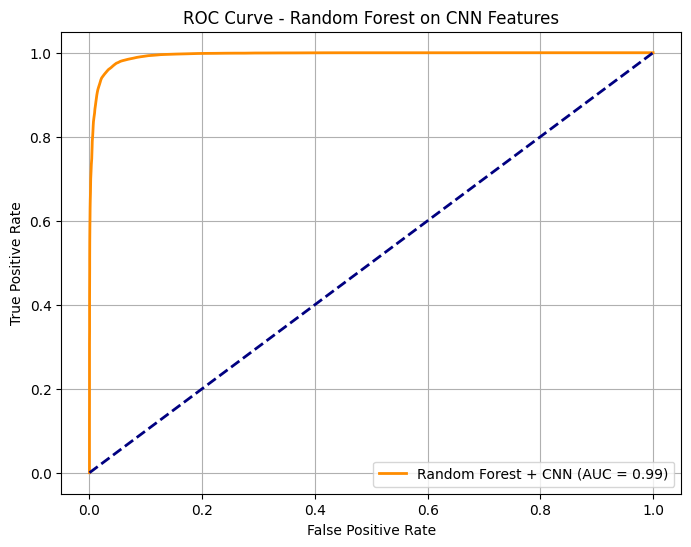

AUC Score: 0.9941


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_proba_rf_cnn = rf_model.predict_proba(cnn_features_test)[:, 1]

# Compute ROC curve and AUC
fpr_rf_cnn, tpr_rf_cnn, _ = roc_curve(y_test, y_proba_rf_cnn)
roc_auc_rf_cnn = auc(fpr_rf_cnn, tpr_rf_cnn)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_cnn, tpr_rf_cnn, color='darkorange', lw=2, label=f'Random Forest + CNN (AUC = {roc_auc_rf_cnn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest on CNN Features')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Print AUC
print(f"AUC Score: {roc_auc_rf_cnn:.4f}")


In [ ]:
y_pred_rf_cnn = y_pred_rf

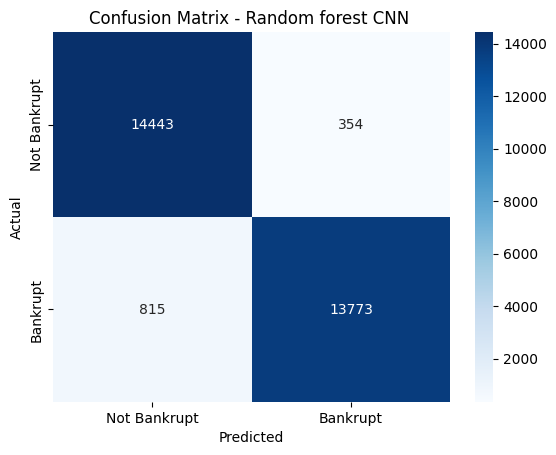

In [ ]:
from sklearn.metrics import roc_curve, auc , confusion_matrix
conf_matrix = confusion_matrix(y_test,y_pred_rf_cnn)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - Random forest CNN ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



3. Random Forest ML




In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(random_state=42)

# Lightweight parameter grid for fast execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search with 3-fold CV for speed
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy on test data: 0.8174578866768759
Classification report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83     14797
           1       0.86      0.76      0.81     14588

    accuracy                           0.82     29385
   macro avg       0.82      0.82      0.82     29385
weighted avg       0.82      0.82      0.82     29385



In [ ]:
y_pred_rf_ml = y_pred

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)

# Print Accuracy
print("Accuracy on test data:", accuracy_score(y_test, y_pred))

# Print Classification Report
print("Classification report:\n", classification_report(y_test, y_pred))

# Overall scores (weighted to handle imbalance)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Precision (weighted): {precision:.4f}")
print(f"Overall Recall (weighted): {recall:.4f}")
print(f"Overall F1 Score (weighted): {f1:.4f}")


Accuracy on test data: 0.8174578866768759
Classification report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83     14797
           1       0.86      0.76      0.81     14588

    accuracy                           0.82     29385
   macro avg       0.82      0.82      0.82     29385
weighted avg       0.82      0.82      0.82     29385


Overall Precision (weighted): 0.8215
Overall Recall (weighted): 0.8175
Overall F1 Score (weighted): 0.8168


Accuracy on test data: 0.8174578866768759

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83     14797
           1       0.86      0.76      0.81     14588

    accuracy                           0.82     29385
   macro avg       0.82      0.82      0.82     29385
weighted avg       0.82      0.82      0.82     29385



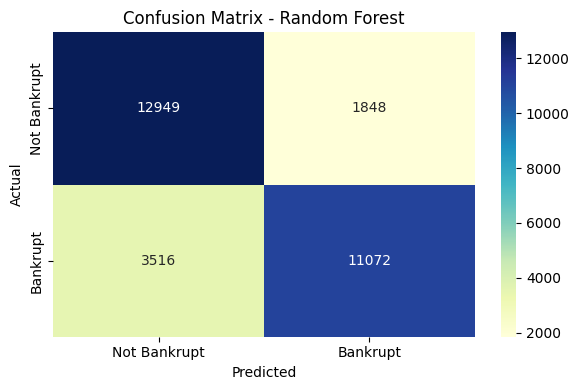

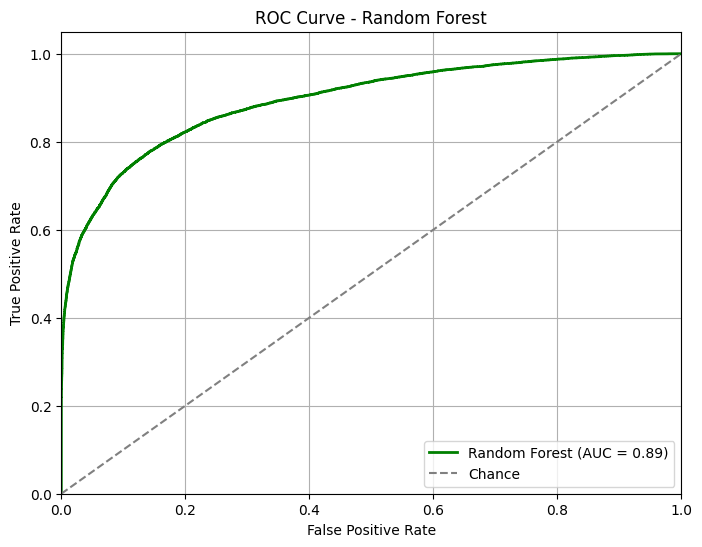

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score

# === Predict class probabilities ===
y_proba_rf = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# === Predict class labels ===
y_pred = grid_search.best_estimator_.predict(X_test)

# === Accuracy & classification report ==
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# === Confusion Matrix ===
conf_matrix = confusion_matrix(y_test, y_pred_rf_ml)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu",
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# === ROC Curve and AUC ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# import shap

# # Initialize TreeExplainer for Random Forest
# explainer = shap.TreeExplainer(rf_model)

# # Explain predictions on test set
# shap_values = explainer.shap_values(cnn_features_test)

# # Plot summary (global feature importance)
# shap.summary_plot(shap_values[1], cnn_features_test, feature_names=[f'feat_{i}' for i in range(cnn_features_test.shape[1])])


Test Accuracy: 70.83%


# **Logistic Regression**

5. logistic Regression + CNN




 Logistic Regression on CNN Features Accuracy: 75.14%

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76     14797
           1       0.77      0.70      0.74     14588

    accuracy                           0.75     29385
   macro avg       0.75      0.75      0.75     29385
weighted avg       0.75      0.75      0.75     29385



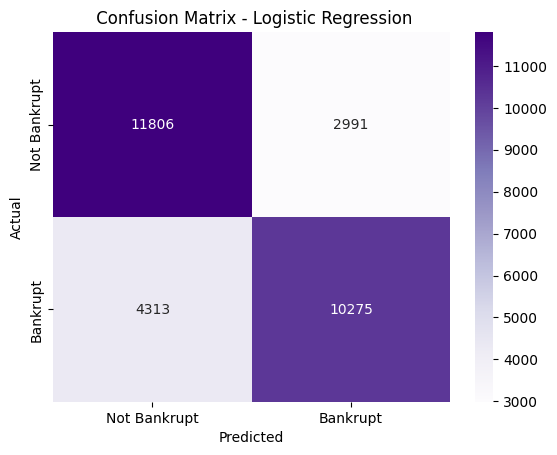

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Set CNN to evaluation mode
model.eval()

# Extract features from CNN
with torch.no_grad():
    cnn_train_features = model.feature_extractor(X_train_tensor).numpy()
    cnn_test_features = model.feature_extractor(X_test_tensor).numpy()

# Train Logistic Regression on CNN features
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(cnn_train_features, y_train)

# Predict on test data
y_pred_log = log_reg_model.predict(cnn_test_features)

#  Accuracy
accuracy = accuracy_score(y_test, y_pred_log)
print(f" Logistic Regression on CNN Features Accuracy: {accuracy * 100:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_log)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title(" Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
y_pred_log_cnn = y_pred_log


Overall Weighted F1 Score: 0.7509
Overall Weighted Recall: 0.7514
Overall Weighted Precision: 0.7533
ROC AUC Score: 0.8357


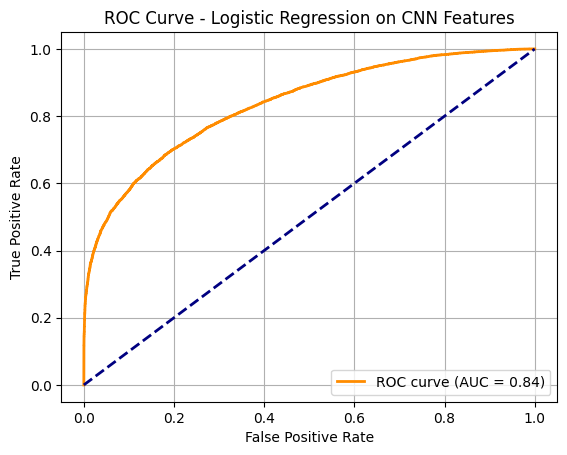

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, roc_curve

# --- Overall metrics ---
f1 = f1_score(y_test, y_pred_log, average='weighted')
recall = recall_score(y_test, y_pred_log, average='weighted')
precision = precision_score(y_test, y_pred_log, average='weighted')

print(f"\nOverall Weighted F1 Score: {f1:.4f}")
print(f"Overall Weighted Recall: {recall:.4f}")
print(f"Overall Weighted Precision: {precision:.4f}")

# --- AUC and ROC Curve ---
# If using binary classification (0 and 1)
y_prob_log = log_reg_model.predict_proba(cnn_test_features)[:, 1]  # probability for class 1

auc_lr_cnn = roc_auc_score(y_test, y_prob_log)
print(f"ROC AUC Score: {auc_lr_cnn:.4f}")

# Plot ROC curve
fpr_lr_cnn, tpr_lr_cnn, _ = roc_curve(y_test, y_prob_log)

plt.figure()
plt.plot(fpr_lr_cnn, tpr_lr_cnn, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_lr_cnn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression on CNN Features')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


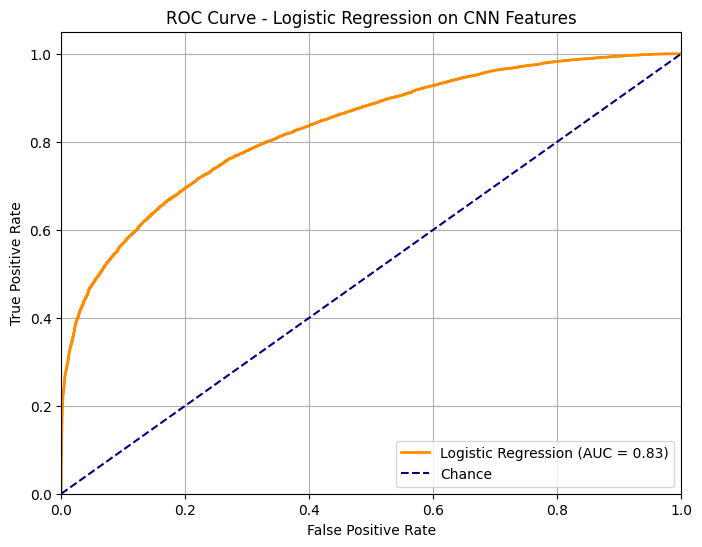

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found:  {'C': 10, 'penalty': 'l2'}
Accuracy on test data: 0.6505359877488515
Classification report:
               precision    recall  f1-score   support

           0       0.64      0.72      0.67     14797
           1       0.67      0.58      0.62     14588

    accuracy                           0.65     29385
   macro avg       0.65      0.65      0.65     29385
weighted avg       0.65      0.65      0.65     29385



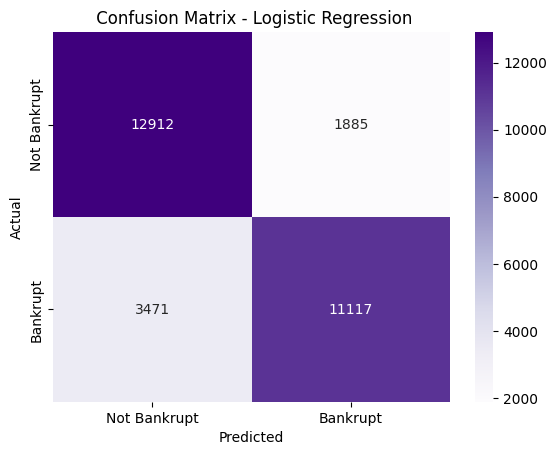

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title(" Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


6.logistic Regresion

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Example: loading your data
# df = pd.read_csv('your_data.csv')
# X = df.drop('target', axis=1)
# y = df['target']

# Split your data (assuming X and y are defined)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(solver='liblinear', random_state=42)

# Parameter grid
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.1, 1, 10]
}

# Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=lr, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters found:  {'C': 10, 'penalty': 'l2'}
Accuracy on test data: 0.6501616470988599
Classification report:
               precision    recall  f1-score   support

           0       0.63      0.72      0.67     14797
           1       0.67      0.58      0.62     14588

    accuracy                           0.65     29385
   macro avg       0.65      0.65      0.65     29385
weighted avg       0.65      0.65      0.65     29385



In [ ]:
y_pred_log_ml = grid_search.best_estimator_.predict(X_test)

Overall Weighted Precision: 0.6525
Overall Weighted Recall: 0.6502
Overall Weighted F1 Score: 0.6484
AUC Score: 0.7606


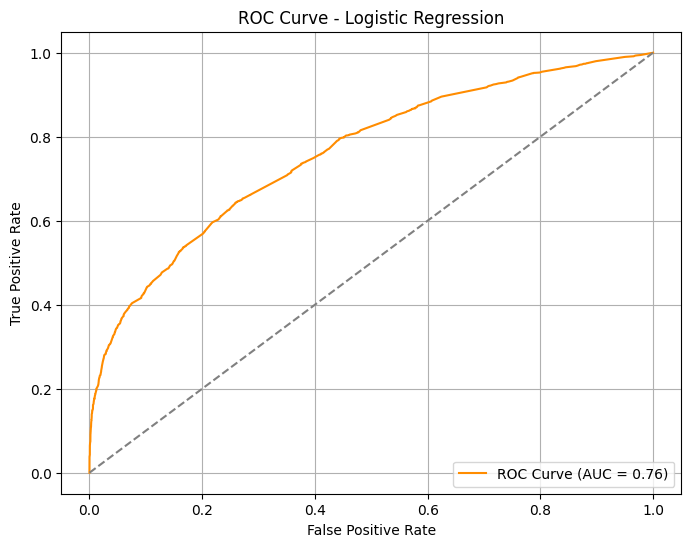

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Overall metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Overall Weighted Precision: {precision:.4f}")
print(f"Overall Weighted Recall: {recall:.4f}")
print(f"Overall Weighted F1 Score: {f1:.4f}")

# AUC (requires probabilities)
y_proba_lr = grid_search.best_estimator_.predict_proba(X_test)[:, 1]  # Probabilities for positive class
auc_score_lr = roc_auc_score(y_test, y_proba)
print(f"AUC Score: {auc_score_lr:.4f}")

# ROC Curve
fpr_lr, tpr_lr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"ROC Curve (AUC = {auc_score_lr:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)


confusion matrix

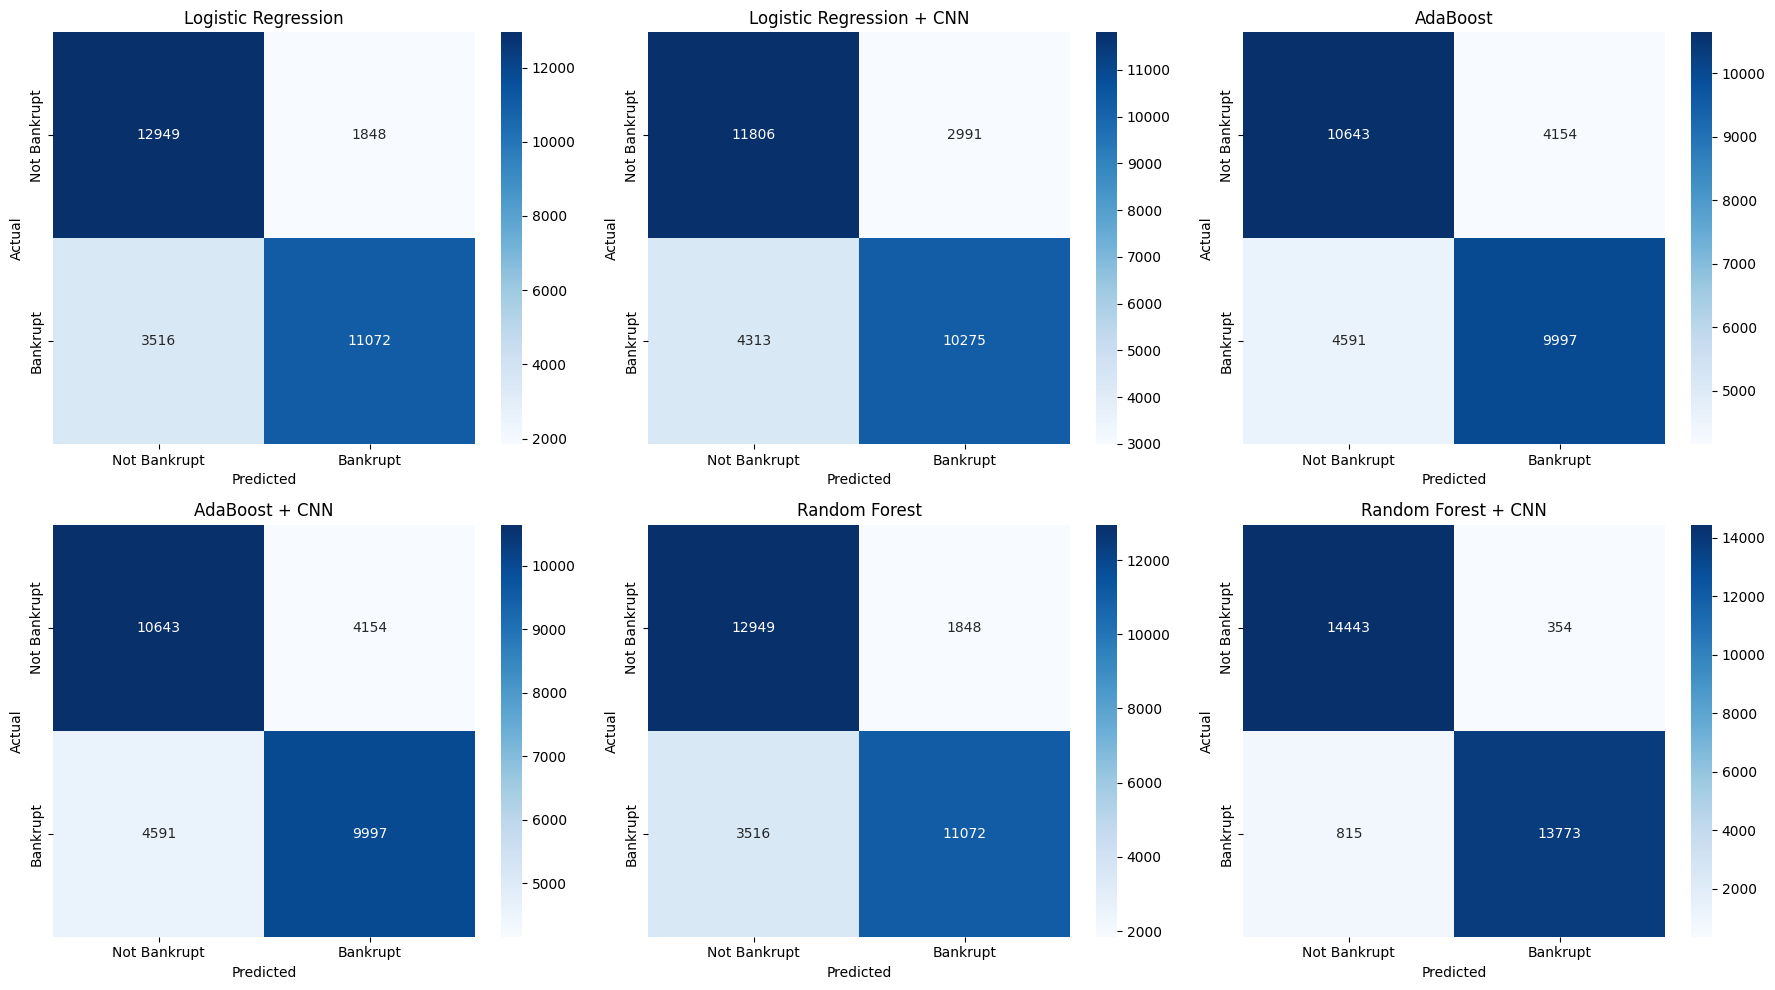

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Collect predictions for each model (already predicted)
models = {
    'Logistic Regression': y_pred_log_ml,
    'Logistic Regression + CNN': y_pred_log_cnn,
    'AdaBoost': y_pred_ada,
    'AdaBoost + CNN': y_pred_ada_cnn,
    'Random Forest': y_pred_rf_ml,
    'Random Forest + CNN': y_pred_rf_cnn
}

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (title, y_pred) in enumerate(models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Bankrupt', 'Bankrupt'],
                yticklabels=['Not Bankrupt', 'Bankrupt'],
                ax=axes[idx])
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


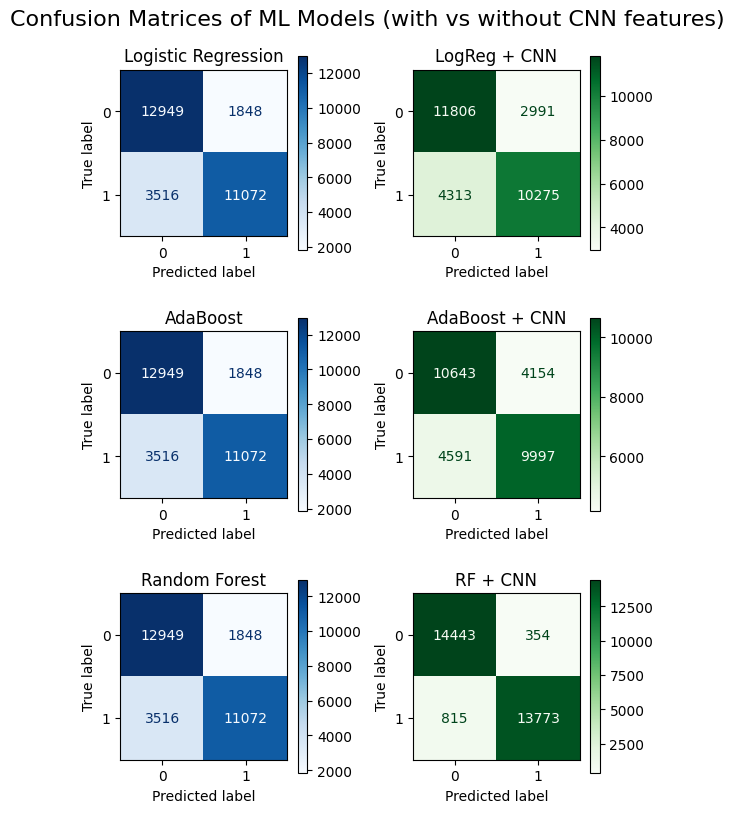

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define your model pairs
model_pairs = [
    ('Logistic Regression', y_test, y_pred_log_ml, 'LogReg + CNN', y_pred_log_cnn),
    ('AdaBoost', y_test, y_pred_ada_ml, 'AdaBoost + CNN', y_pred_ada_cnn),
    ('Random Forest', y_test, y_pred_rf_ml, 'RF + CNN', y_pred_rf_cnn)
]

# Create a 3-row, 2-column plot
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(6, 8))

for i, (model1, y_true1, y_pred1, model2, y_pred2) in enumerate(model_pairs):
    # First model confusion matrix
    cm1 = confusion_matrix(y_true1, y_pred1)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
    disp1.plot(ax=axes[i, 0], values_format='d', cmap='Blues')
    axes[i, 0].set_title(model1)

    # Second model confusion matrix
    cm2 = confusion_matrix(y_true1, y_pred2)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
    disp2.plot(ax=axes[i, 1], values_format='d', cmap='Greens')
    axes[i, 1].set_title(model2)

plt.tight_layout()
plt.suptitle("Confusion Matrices of ML Models (with vs without CNN features)", fontsize=16, y=1.02)
plt.show()


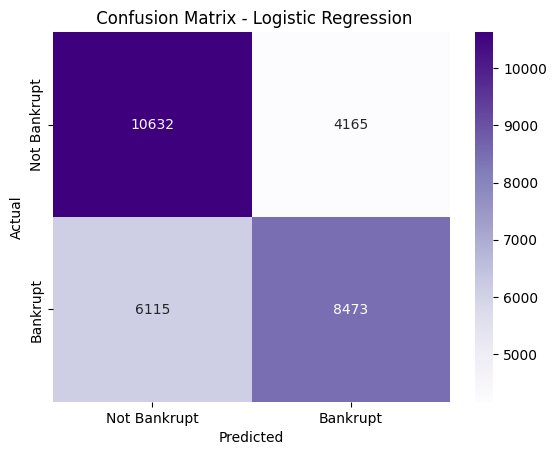

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
con_matrix = confusion_matrix(y_test,y_pred)
sns.heatmap(con_matrix, annot=True, fmt="d", cmap="Purples", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title(" Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score_lr:.2f})', linestyle='--')
plt.plot(fpr_lr_cnn, tpr_lr_cnn, label=f'Logistic Regression + CNN (AUC = {auc_lr_cnn:.2f})')

plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})', linestyle='--')
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f'AdaBoost + CNN (AUC = {auc_score_ada_cnn:.2f})')

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linestyle='--')
plt.plot(fpr_rf_cnn, tpr_rf_cnn, label=f'Random Forest + CNN (AUC = {roc_auc_rf_cnn:.2f})')

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot formatting
plt.title("ROC Curves for Logistic Regression, AdaBoost, Random Forest (With & Without CNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

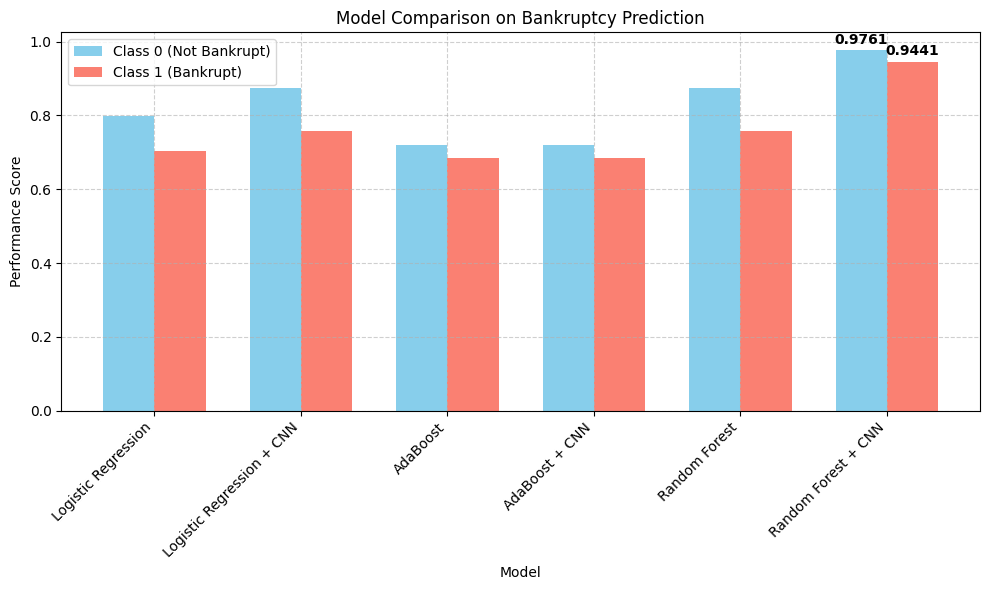

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame with the performance values
data = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression + CNN",
        "AdaBoost",
        "AdaBoost + CNN",
        "Random Forest",
        "Random Forest + CNN"
    ],
    "Class 0 (Not Bankrupt)": [
        0.7978,
        0.8753,
        0.7194,
        0.7194,
        0.8753,
        0.9761
    ],
    "Class 1 (Bankrupt)": [
        0.7046,
        0.7590,
        0.6853,
        0.6853,
        0.7590,
        0.9441
    ]
}

df = pd.DataFrame(data)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(df))

bar_width = 0.35
ax.bar([i - bar_width/2 for i in x], df["Class 0 (Not Bankrupt)"],
       width=bar_width, label="Class 0 (Not Bankrupt)", color='skyblue')
ax.bar([i + bar_width/2 for i in x], df["Class 1 (Bankrupt)"],
       width=bar_width, label="Class 1 (Bankrupt)", color='salmon')

# Annotate best values
best_class0_idx = df["Class 0 (Not Bankrupt)"].idxmax()
best_class1_idx = df["Class 1 (Bankrupt)"].idxmax()

ax.text(best_class0_idx - bar_width/2, df.loc[best_class0_idx, "Class 0 (Not Bankrupt)"] + 0.01,
        f"{df.loc[best_class0_idx, 'Class 0 (Not Bankrupt)']:.4f}", ha='center', va='bottom', fontweight='bold')
ax.text(best_class1_idx + bar_width/2, df.loc[best_class1_idx, "Class 1 (Bankrupt)"] + 0.01,
        f"{df.loc[best_class1_idx, 'Class 1 (Bankrupt)']:.4f}", ha='center', va='bottom', fontweight='bold')

# Set labels and title
ax.set_xlabel("Model")
ax.set_ylabel("Performance Score")
ax.set_title("Model Comparison on Bankruptcy Prediction")
ax.set_xticks(x)
ax.set_xticklabels(df["Model"], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


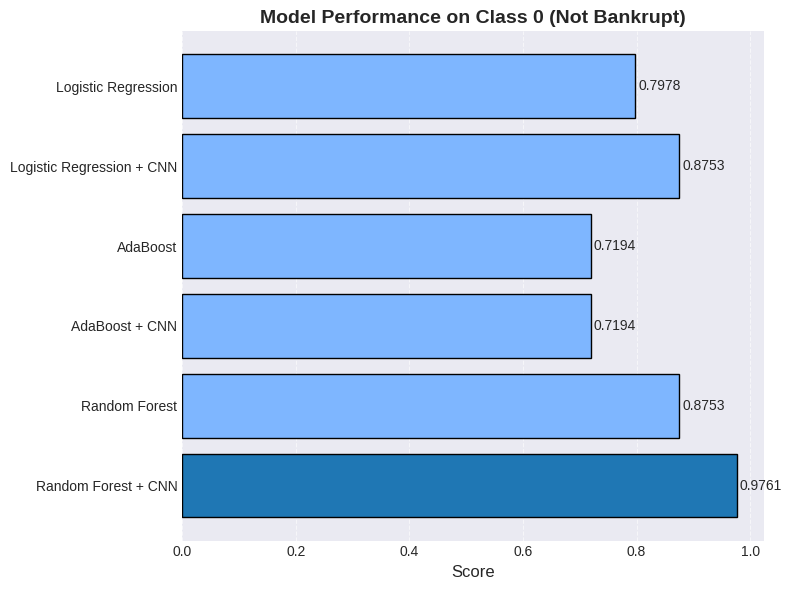

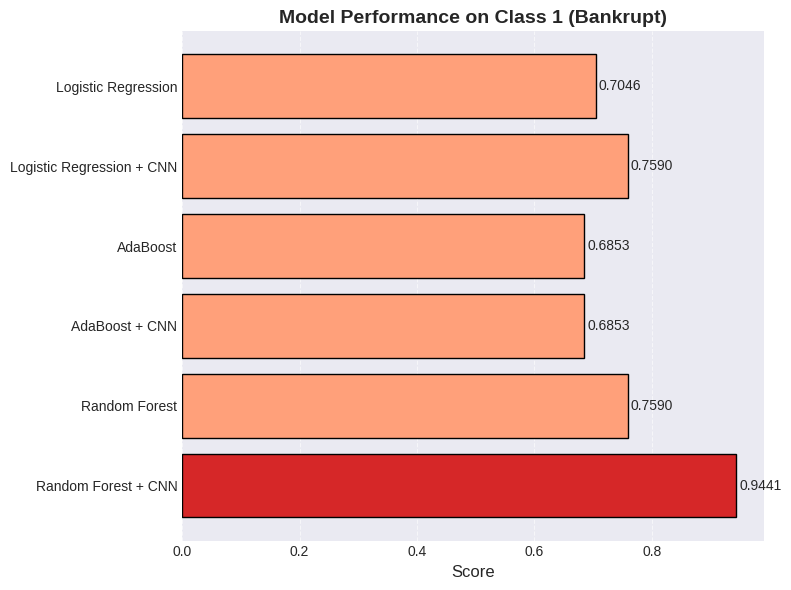

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use a clean style
plt.style.use('seaborn-v0_8-dark')  # or 'ggplot', 'seaborn-whitegrid'

# Define data
data = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression + CNN",
        "AdaBoost",
        "AdaBoost + CNN",
        "Random Forest",
        "Random Forest + CNN"
    ],
    "Class 0 (Not Bankrupt)": [
        0.7978,
        0.8753,
        0.7194,
        0.7194,
        0.8753,
        0.9761
    ],
    "Class 1 (Bankrupt)": [
        0.7046,
        0.7590,
        0.6853,
        0.6853,
        0.7590,
        0.9441
    ]
}

df = pd.DataFrame(data)

def plot_class_performance(class_name, color, highlight_color):
    scores = df[class_name]
    best_idx = scores.idxmax()

    colors = [highlight_color if i == best_idx else color for i in range(len(scores))]

    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(df["Model"], scores, color=colors, edgecolor='black')

    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
                f"{score:.4f}", va='center', fontsize=10)

    ax.set_xlabel("Score", fontsize=12)
    ax.set_title(f"Model Performance on {class_name}", fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Plot for Class 0 (Not Bankrupt)
plot_class_performance("Class 0 (Not Bankrupt)", color="#7EB6FF", highlight_color="#1F77B4")

# Plot for Class 1 (Bankrupt)
plot_class_performance("Class 1 (Bankrupt)", color="#FFA07A", highlight_color="#D62728")


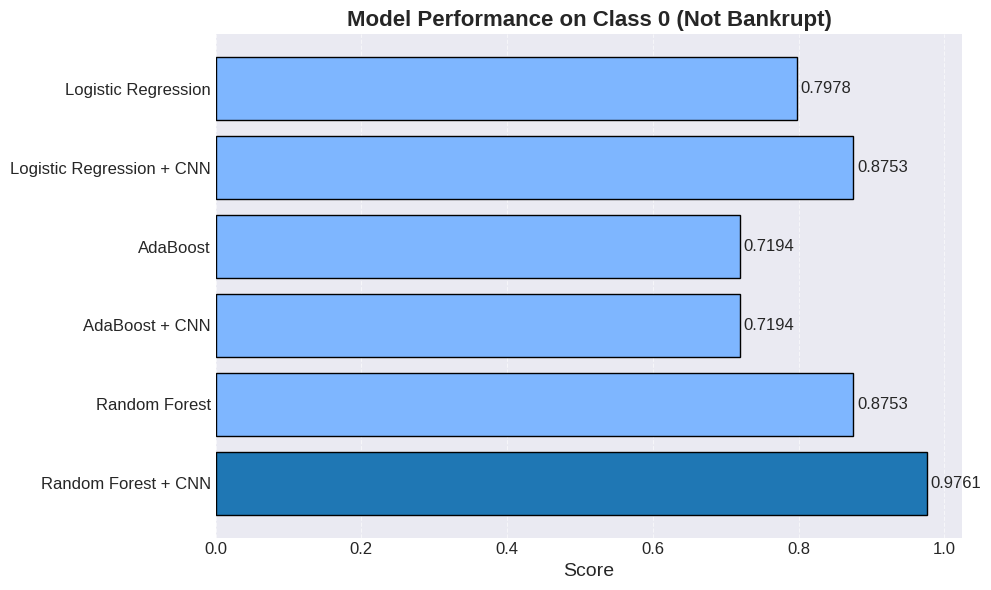

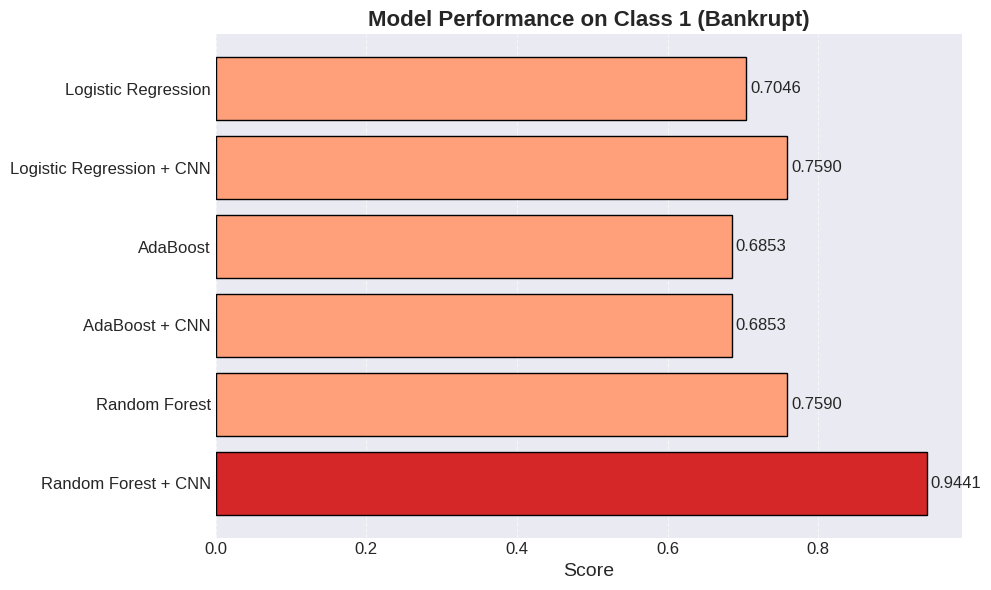

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define data
data = {
    "Model": [
        "Logistic Regression",
        "Logistic Regression + CNN",
        "AdaBoost",
        "AdaBoost + CNN",
        "Random Forest",
        "Random Forest + CNN"
    ],
    "Class 0 (Not Bankrupt)": [
        0.7978,
        0.8753,
        0.7194,
        0.7194,
        0.8753,
        0.9761
    ],
    "Class 1 (Bankrupt)": [
        0.7046,
        0.7590,
        0.6853,
        0.6853,
        0.7590,
        0.9441
    ]
}

df = pd.DataFrame(data)

def plot_class_performance(class_name, color, highlight_color):
    scores = df[class_name]
    best_idx = scores.idxmax()

    colors = [highlight_color if i == best_idx else color for i in range(len(scores))]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(df["Model"], scores, color=colors, edgecolor='black')

    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
                f"{score:.4f}", va='center', fontsize=12)

    ax.set_xlabel("Score", fontsize=14)
    ax.set_title(f"Model Performance on {class_name}", fontsize=16, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    # Customizing tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    plt.show()

# Plot for Class 0 (Not Bankrupt)
plot_class_performance("Class 0 (Not Bankrupt)", color="#7EB6FF", highlight_color="#1F77B4")

# Plot for Class 1 (Bankrupt)
plot_class_performance("Class 1 (Bankrupt)", color="#FFA07A", highlight_color="#D62728")


# **Result compariision**

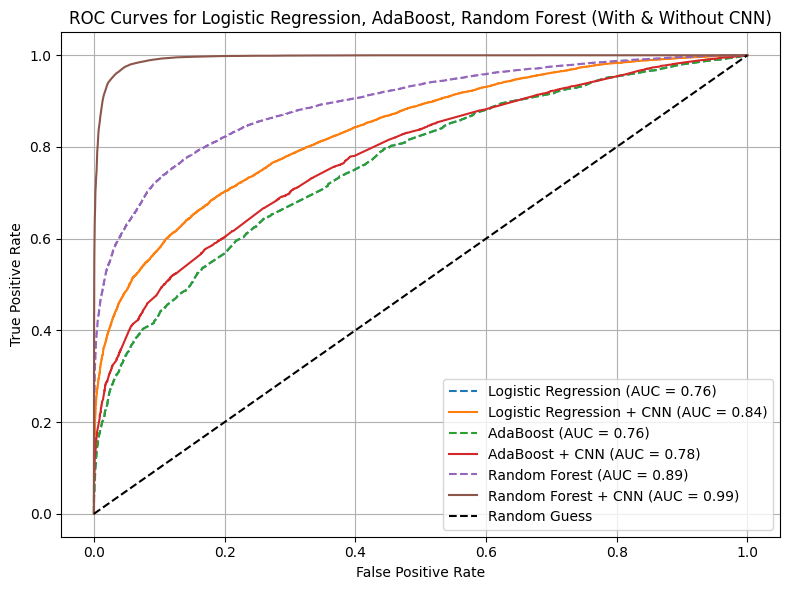

In [ ]:
# Plotting all ROC curves
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_score_lr:.2f})', linestyle='--')
plt.plot(fpr_lr_cnn, tpr_lr_cnn, label=f'Logistic Regression + CNN (AUC = {auc_lr_cnn:.2f})')

plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})', linestyle='--')
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f'AdaBoost + CNN (AUC = {auc_score_ada_cnn:.2f})')

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linestyle='--')
plt.plot(fpr_rf_cnn, tpr_rf_cnn, label=f'Random Forest + CNN (AUC = {roc_auc_rf_cnn:.2f})')

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot formatting
plt.title("ROC Curves for Logistic Regression, AdaBoost, Random Forest (With & Without CNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

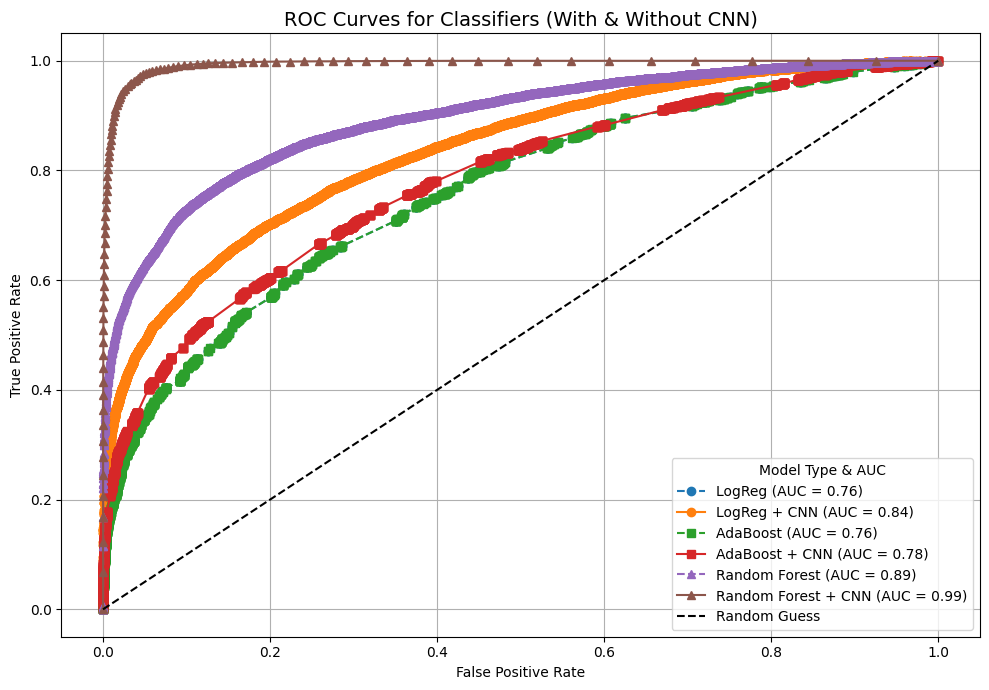

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Logistic Regression
plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_score_lr:.2f})', linestyle='--', marker='o')
plt.plot(fpr_lr_cnn, tpr_lr_cnn, label=f'LogReg + CNN (AUC = {auc_lr_cnn:.2f})', linestyle='-', marker='o')

# AdaBoost
plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})', linestyle='--', marker='s')
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f'AdaBoost + CNN (AUC = {auc_score_ada_cnn:.2f})', linestyle='-', marker='s')

# Random Forest
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linestyle='--', marker='^')
plt.plot(fpr_rf_cnn, tpr_rf_cnn, label=f'Random Forest + CNN (AUC = {roc_auc_rf_cnn:.2f})', linestyle='-', marker='^')

# Reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot styling
plt.title("ROC Curves for Classifiers (With & Without CNN)", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)

# Refined legend
plt.legend(title='Model Type & AUC', loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


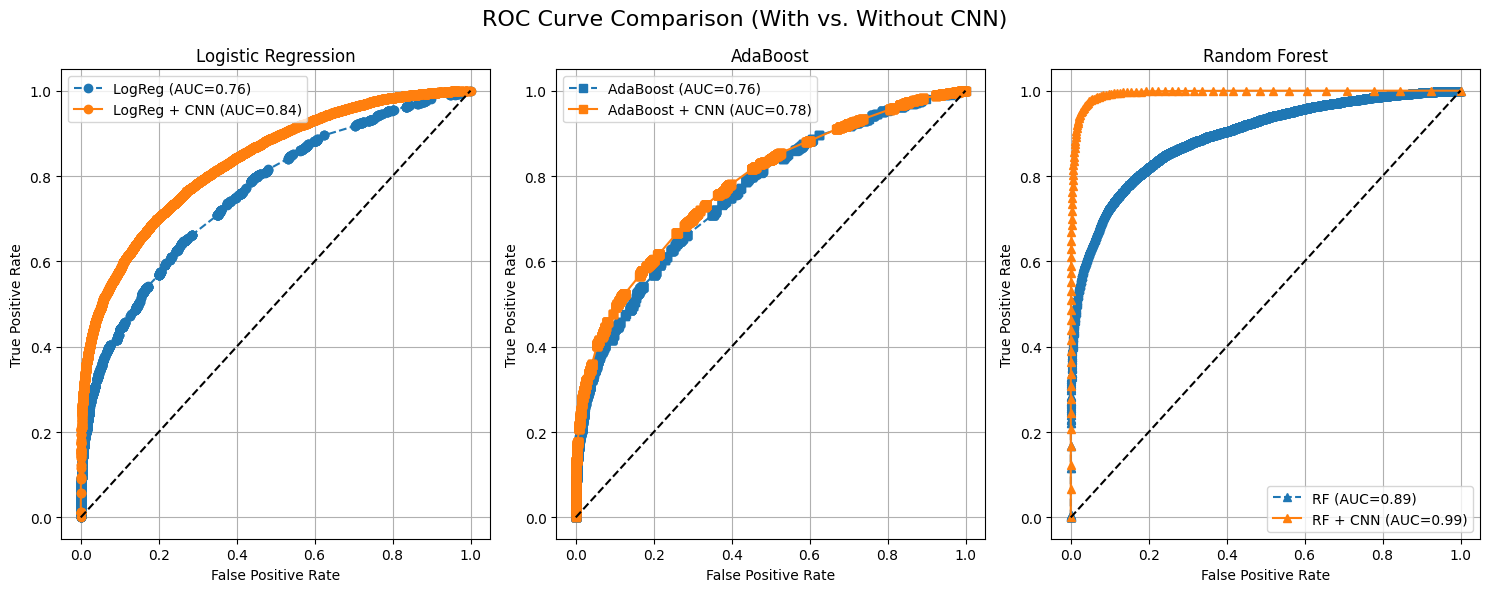

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Plot 1: Logistic Regression
axs[0].plot(fpr_lr, tpr_lr, '--o', label=f'LogReg (AUC={auc_score_lr:.2f})')
axs[0].plot(fpr_lr_cnn, tpr_lr_cnn, '-o', label=f'LogReg + CNN (AUC={auc_lr_cnn:.2f})')
axs[0].plot([0, 1], [0, 1], 'k--')
axs[0].set_title("Logistic Regression")

# Plot 2: AdaBoost
axs[1].plot(fpr_ada, tpr_ada, '--s', label=f'AdaBoost (AUC={roc_auc_ada:.2f})')
axs[1].plot(fpr_ada_cnn, tpr_ada_cnn, '-s', label=f'AdaBoost + CNN (AUC={auc_score_ada_cnn:.2f})')
axs[1].plot([0, 1], [0, 1], 'k--')
axs[1].set_title("AdaBoost")

# Plot 3: Random Forest
axs[2].plot(fpr_rf, tpr_rf, '--^', label=f'RF (AUC={roc_auc_rf:.2f})')
axs[2].plot(fpr_rf_cnn, tpr_rf_cnn, '-^', label=f'RF + CNN (AUC={roc_auc_rf_cnn:.2f})')
axs[2].plot([0, 1], [0, 1], 'k--')
axs[2].set_title("Random Forest")

for ax in axs:
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True)
    ax.legend()

plt.suptitle("ROC Curve Comparison (With vs. Without CNN)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Add each model
fig.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, mode='lines', name=f'LogReg (AUC={auc_score_lr:.2f})', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=fpr_lr_cnn, y=tpr_lr_cnn, mode='lines', name=f'LogReg + CNN (AUC={auc_lr_cnn:.2f})'))

fig.add_trace(go.Scatter(x=fpr_ada, y=tpr_ada, mode='lines', name=f'AdaBoost (AUC={roc_auc_ada:.2f})', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=fpr_ada_cnn, y=tpr_ada_cnn, mode='lines', name=f'AdaBoost + CNN (AUC={auc_score_ada_cnn:.2f})'))

fig.add_trace(go.Scatter(x=fpr_rf, y=tpr_rf, mode='lines', name=f'RF (AUC={roc_auc_rf:.2f})', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=fpr_rf_cnn, y=tpr_rf_cnn, mode='lines', name=f'RF + CNN (AUC={roc_auc_rf_cnn:.2f})'))

# Diagonal line
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random Guess', line=dict(dash='dot', color='black')))

fig.update_layout(
    title="Interactive ROC Curve - Classifier Comparison",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    width=900,
    height=600,
    template="plotly_white"
)
fig.show()


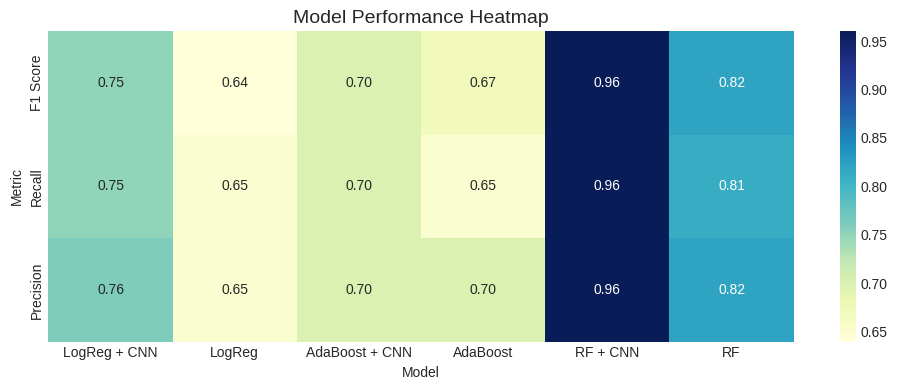

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {
    'LogReg + CNN': [0.75, 0.75, 0.76],
    'LogReg': [0.64, 0.65, 0.65],
    'AdaBoost + CNN': [0.7, 0.7, 0.7],
    'AdaBoost': [0.67, 0.65, 0.7],
    'RF + CNN': [0.96, 0.96, 0.96],
    'RF': [0.82, 0.81, 0.82]
}
df = pd.DataFrame(data, index=['F1 Score', 'Recall', 'Precision'])

# Plot
plt.figure(figsize=(10, 4))
sns.heatmap(df, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Model Performance Heatmap", fontsize=14)
plt.ylabel("Metric")
plt.xlabel("Model")
plt.tight_layout()
plt.show()


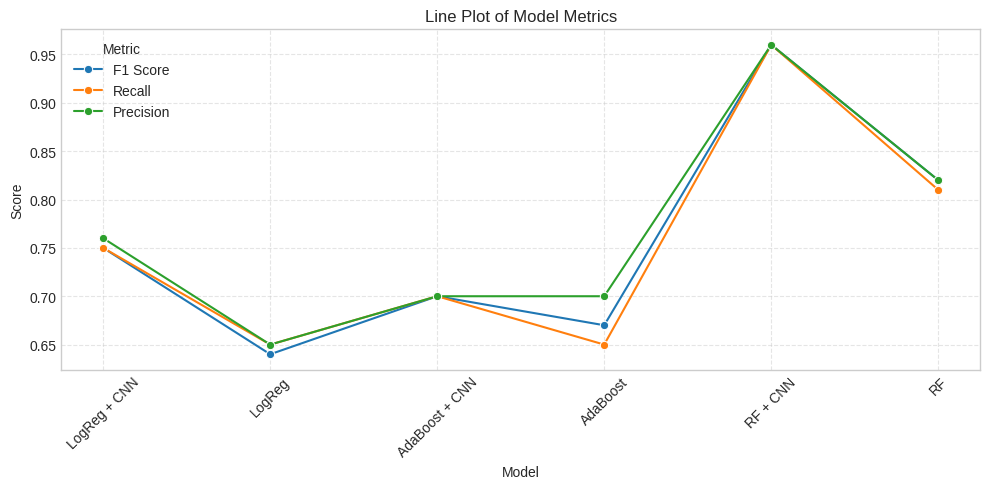

In [ ]:
df_melted = df.T.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
df_melted.rename(columns={'index': 'Model'}, inplace=True)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_melted, x='Model', y='Score', hue='Metric', marker='o')
plt.title("Line Plot of Model Metrics")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# **using the machine learning model**

In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import accuracy_score, classification_report
# from scipy.stats import randint

# # Define the Random Forest model
# rf = RandomForestClassifier(random_state=42)

# # Define the hyperparameter space
# param_dist = {
#     'n_estimators': randint(100, 1000),
#     'max_depth': randint(5, 50),
#     'min_samples_split': randint(2, 20),
#     'min_samples_leaf': randint(1, 20),
#     'max_features': ['auto', 'sqrt', 'log2']
# }

# # Randomized search
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#          # 5-fold cross-validation
#     verbose=1,
#     n_jobs=-1,
#     random_state=42,
#     scoring='accuracy'
# )

# # Fit to training data
# random_search.fit(X_train, y_train)

# # Best model
# best_rf = random_search.best_estimator_

# # Predict on test set
# y_pred = best_rf.predict(X_test)

# # Evaluation
# print("Best Parameters:", random_search.best_params_)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# # Assuming smote_df is already defined and preprocessed
# X = smote_df.drop("status_label", axis=1).values
# y = smote_df["status_label_Encoded"].values

# # Scale the features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define the model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:58:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters found:  {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9336396120469628
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.94     14797
           1       0.96      0.90      0.93     14588

    accuracy                           0.93     29385
   macro avg       0.94      0.93      0.93     29385
weighted avg       0.94      0.93      0.93     29385

Accuracy: 0.9336396120469628


SVM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC

In [ ]:
svm = SVC()

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=svm, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(random_state=42)

# Lightweight parameter grid for fast execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search with 3-fold CV for speed
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters found:  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy on test data: 0.8177301344223243
Classification report:
               precision    recall  f1-score   support

           0       0.79      0.87      0.83     14797
           1       0.86      0.76      0.81     14588

    accuracy                           0.82     29385
   macro avg       0.82      0.82      0.82     29385
weighted avg       0.82      0.82      0.82     29385



In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Assuming smote_df is already defined and preprocessed
X = smote_df.drop(["status_label", "status_label_Encoded"], axis=1).values
y = smote_df["status_label_Encoded"].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define Random Forest model
rf = RandomForestClassifier(random_state=42)

# Lightweight parameter grid for fast execution
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Grid search with 3-fold CV for speed
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2d9026ae4e94d1b252e23b08c0b0a57f51d8f40913b87195983ee1331189e879
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built Lime


In [ ]:

# Confusion Matrix


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters found:  {'C': 10, 'penalty': 'l2'}
Accuracy on test data: 0.6505359877488515
Classification report:
               precision    recall  f1-score   support

           0       0.64      0.72      0.67     14797
           1       0.67      0.58      0.62     14588

    accuracy                           0.65     29385
   macro avg       0.65      0.65      0.65     29385
weighted avg       0.65      0.65      0.65     29385



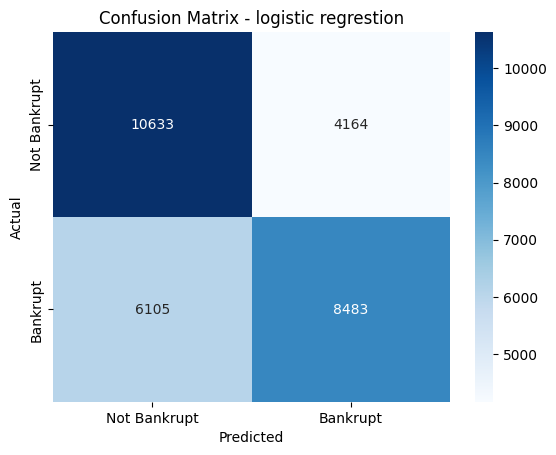

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - logistic regrestion")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 **ada boost**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score



# Define base estimator: shallow tree for speed
base_estimator = DecisionTreeClassifier(max_depth=1)

# Define AdaBoost model
ada = AdaBoostClassifier(estimator=base_estimator, random_state=42)

# Lightweight parameter grid for fast execution
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.5, 1.0]
}

# Grid search with 3-fold CV for speed
grid_search = GridSearchCV(estimator=ada, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters found:  {'learning_rate': 1.0, 'n_estimators': 100}
Accuracy on test data: 0.6906925302024842
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70     14797
           1       0.70      0.65      0.68     14588

    accuracy                           0.69     29385
   macro avg       0.69      0.69      0.69     29385
weighted avg       0.69      0.69      0.69     29385



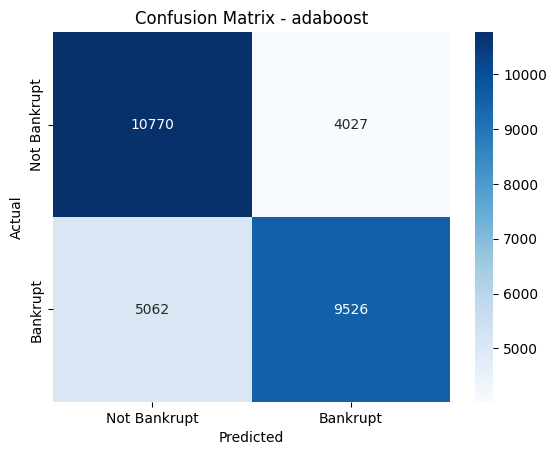

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Bankrupt', 'Bankrupt'],
            yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.title("Confusion Matrix - adaboost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# import lime
# import lime.lime_tabular
# import matplotlib.pyplot as plt

# # Get feature names
# feature_names = smote_df.drop(columns=["status_label", "status_label_Encoded"]).columns

# # Create LIME explainer
# explainer = lime.lime_tabular.LimeTabularExplainer(
#     training_data=X_train,
#     feature_names=feature_names,
#     class_names=['Not Bankrupt', 'Bankrupt'],
#     mode='classification',
#     verbose=True,
#     discretize_continuous=True
# )

# # Pick an instance to explain
# i = 0  # Index of the test instance to explain
# exp = explainer.explain_instance(
#     X_test[i],
#     grid_search.best_estimator_.predict_proba,
#     num_features=10
# )

# # Show explanation in notebook or plot
# exp.show_in_notebook(show_table=True)
# # Or plot as static image
# fig = exp.as_pyplot_figure()
# plt.tight_layout()
# plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Assuming smote_df is already defined and preprocessed
# X = smote_df.drop("status_label", axis=1).values
# y = smote_df["status_label_Encoded"].values

# # Scale the features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# # Define the model
svc = LinearSVC(max_iter=500)

# Define a small parameter grid for faster search
param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

# Grid search with 3-fold cross-validation
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid,
                           cv=3, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters
print("Best parameters found: ", grid_search.best_params_)

# Predict and evaluate
y_pred = grid_search.best_estimator_.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


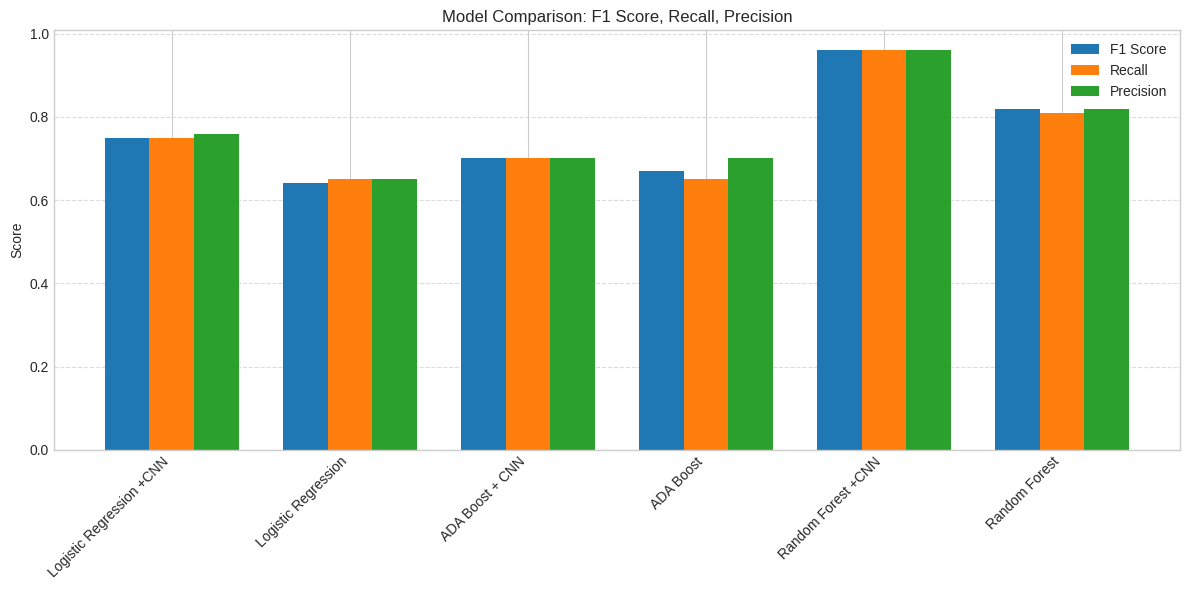

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the data
data = {
    'MODEL': [
        'Logistic Regression +CNN', 'Logistic Regression',
        'ADA Boost + CNN', 'ADA Boost',
        'Random Forest +CNN', 'Random Forest'
    ],
    'f1_score': [0.75, 0.64, 0.7, 0.67, 0.96, 0.82],
    'Recall_value': [0.75, 0.65, 0.7, 0.65, 0.96, 0.81],
    'Precision': [0.76, 0.65, 0.7, 0.7, 0.96, 0.82]
}

df = pd.DataFrame(data)

# Plot
bar_width = 0.25
x = range(len(df['MODEL']))

plt.figure(figsize=(12, 6))

plt.bar([i - bar_width for i in x], df['f1_score'], width=bar_width, label='F1 Score')
plt.bar(x, df['Recall_value'], width=bar_width, label='Recall')
plt.bar([i + bar_width for i in x], df['Precision'], width=bar_width, label='Precision')

# Labels and titles
plt.xticks(x, df['MODEL'], rotation=45, ha='right')
plt.ylabel('Score')
plt.title('Model Comparison: F1 Score, Recall, Precision')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


# accuracy using CNN + ML model
1. Random Forest = 96 %
2. XG BOOST = 90.3 %
3. Logistic Regression = 94.46 %
4. ada BOOst = 71.64%
# accuracy using ML model and optimizer
1. Random Forest = 81%
2. XG BOOST = 93.30%
3. Logistic Regression = 69%
4. ada BOOst = 65 %

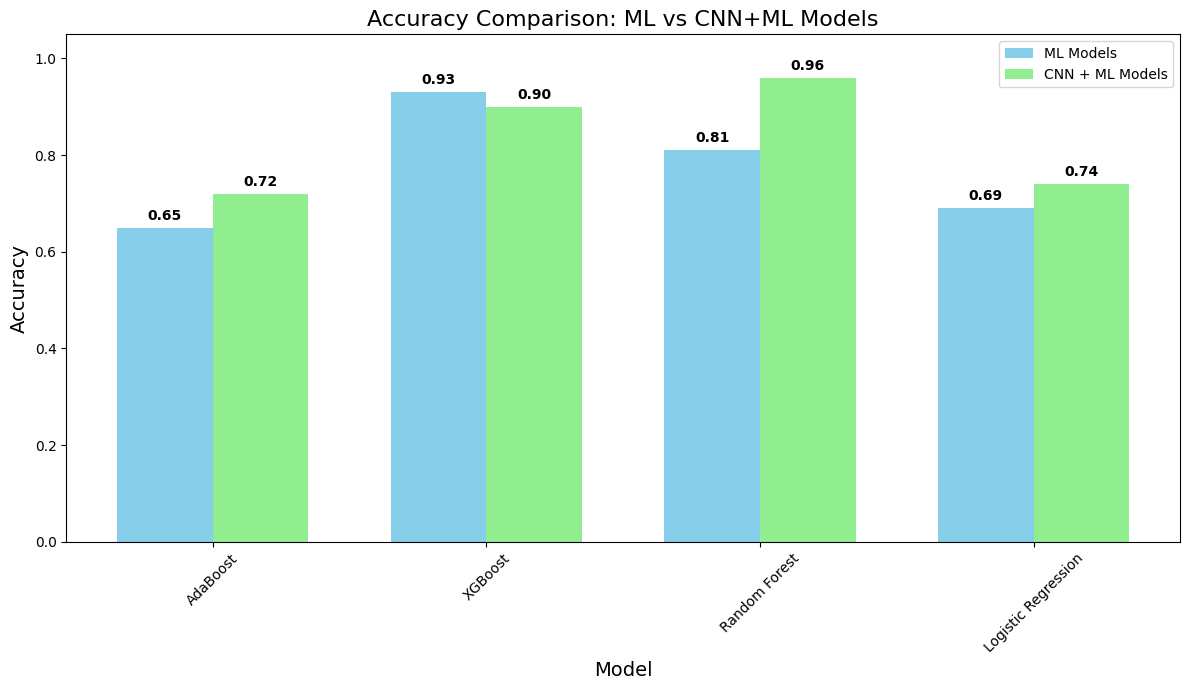

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example accuracy values (replace these with your real numbers)
ml_accuracies = {
    'AdaBoost': 0.65,
    'Random Forest': 0.81,
    'Logistic Regression': 0.69
}

cnn_ml_accuracies = {
    'AdaBoost + CNN': 0.76,
    'Random Forest + CNN': 0.96,
    'Logistic Regression + CNN': 0.74
}

# Create lists
models_ml = list(ml_accuracies.keys())
models_cnn_ml = list(cnn_ml_accuracies.keys())
accuracies_ml = list(ml_accuracies.values())
accuracies_cnn_ml = list(cnn_ml_accuracies.values())

# Set the position of bars on the x-axis
x = np.arange(len(models_ml))  # the label locations
width = 0.35  # width of the bars

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, accuracies_ml, width, label='ML Models', color='skyblue')
bars2 = ax.bar(x + width/2, accuracies_cnn_ml, width, label='CNN + ML Models', color='lightgreen')

# Add text annotations
for bar in bars1 + bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

# Labels and Title
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xlabel('Model', fontsize=14)
ax.set_title('Accuracy Comparison: ML vs CNN+ML Models', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(models_ml, rotation=45)
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

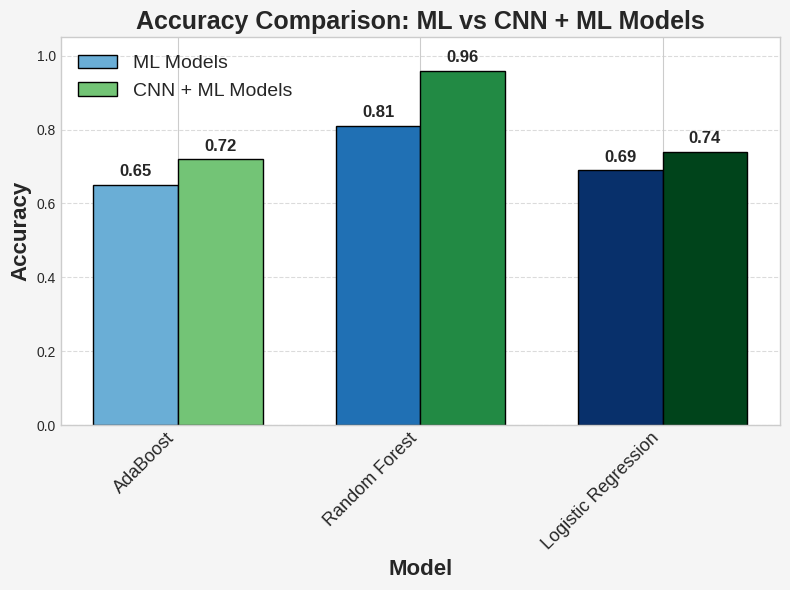

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example accuracy values (replace with real numbers if needed)
ml_accuracies = {
    'AdaBoost': 0.65,
    # 'XGBoost': 0.93,
    'Random Forest': 0.81,
    'Logistic Regression': 0.69
}

cnn_ml_accuracies = {
    'AdaBoost + CNN': 0.72,
    # 'XGBoost + CNN': 0.90,
    'Random Forest + CNN': 0.96,
    'Logistic Regression + CNN': 0.74
}

# Create lists
models_ml = list(ml_accuracies.keys())
accuracies_ml = list(ml_accuracies.values())
accuracies_cnn_ml = list(cnn_ml_accuracies.values())

# Set the position of bars on the x-axis
x = np.arange(len(models_ml))  # the label locations
width = 0.35  # width of the bars

# Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 6))

# Colors
colors_ml = plt.cm.Blues(np.linspace(0.5, 1, len(models_ml)))
colors_cnn_ml = plt.cm.Greens(np.linspace(0.5, 1, len(models_ml)))

# Bars
bars1 = ax.bar(x - width/2, accuracies_ml, width, label='ML Models', color=colors_ml, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, accuracies_cnn_ml, width, label='CNN + ML Models', color=colors_cnn_ml, edgecolor='black', linewidth=1)

# Add text annotations
for bar in bars1 + bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and Title
ax.set_ylabel('Accuracy', fontsize=16, fontweight='bold')
ax.set_xlabel('Model', fontsize=16, fontweight='bold')
ax.set_title('Accuracy Comparison: ML vs CNN + ML Models', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_ml, rotation=45, ha='right', fontsize=13, fontweight='medium')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=14, loc='upper left')

# Background
fig.patch.set_facecolor('whitesmoke')
ax.set_facecolor('white')

# Add grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


# Plotting all ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', linestyle='--')
plt.plot(fpr_lr_cnn, tpr_lr_cnn, label=f'Logistic Regression + CNN (AUC = {auc_lr_cnn:.2f})')

plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {auc_ada:.2f})', linestyle='--')
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f'AdaBoost + CNN (AUC = {auc_ada_cnn:.2f})')

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', linestyle='--')
plt.plot(fpr_rf_cnn, tpr_rf_cnn, label=f'Random Forest + CNN (AUC = {auc_rf_cnn:.2f})')

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot formatting
plt.title("ROC Curves for Logistic Regression, AdaBoost, Random Forest (With & Without CNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


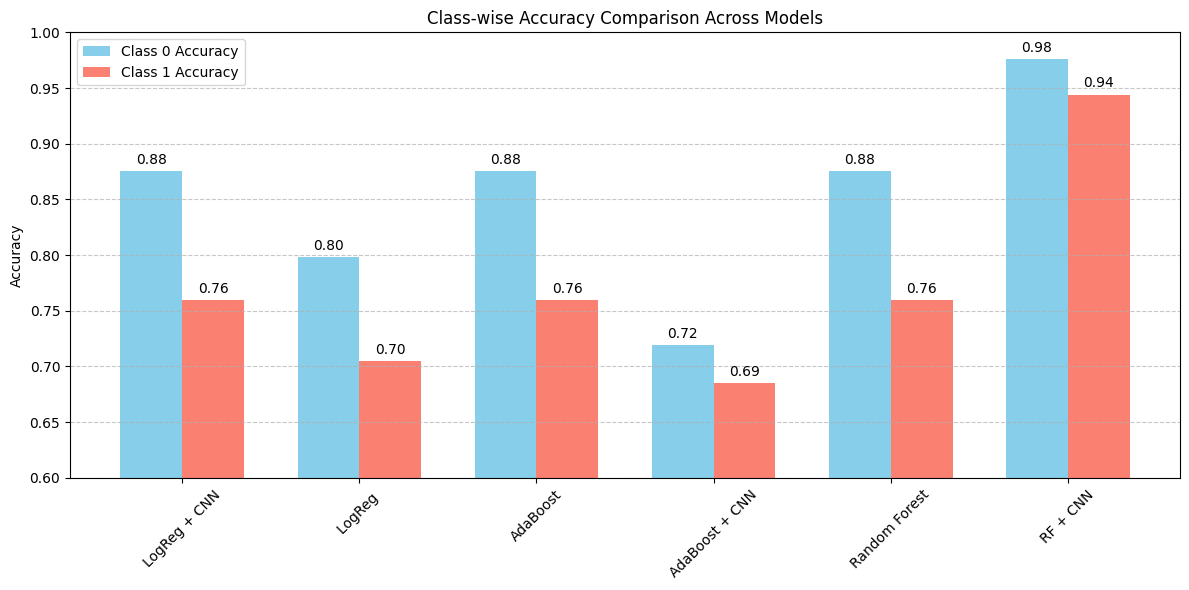

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and accuracy values
models = [
    "LogReg + CNN",
    "LogReg ",
    "AdaBoost",
    "AdaBoost + CNN",
    "Random Forest",
    "RF + CNN"
]

class_0_acc = [0.8752, 0.7979, 0.8752, 0.7194, 0.8752, 0.9761]
class_1_acc = [0.7592, 0.7045, 0.7592, 0.6852, 0.7592, 0.9441]

# Bar width and positions
x = np.arange(len(models))
width = 0.35

# Create the bar plot
plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, class_0_acc, width, label='Class 0 Accuracy', color='skyblue')
bars2 = plt.bar(x + width/2, class_1_acc, width, label='Class 1 Accuracy', color='salmon')

# Labeling
plt.ylabel('Accuracy')
plt.title('Class-wise Accuracy Comparison Across Models')
plt.xticks(x, models, rotation=45)
plt.ylim(0.6, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on top of bars
for bar in bars1 + bars2:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


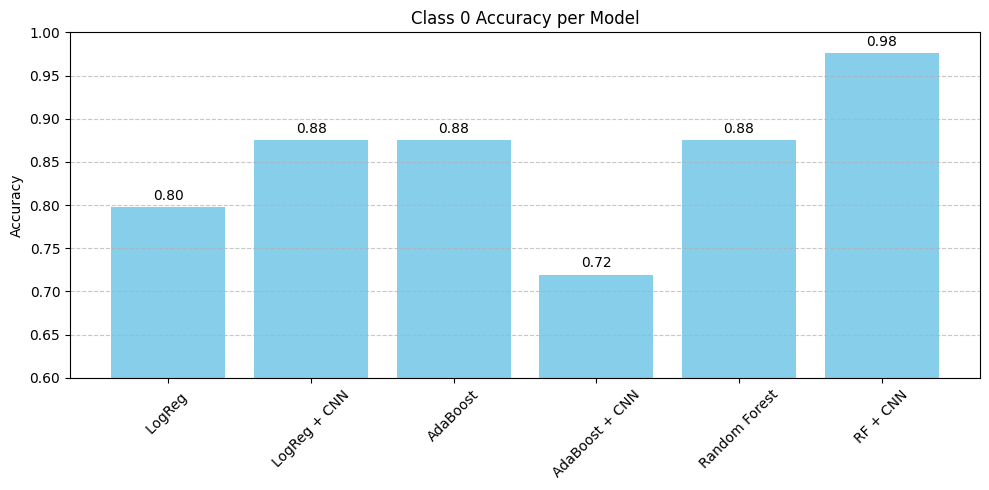

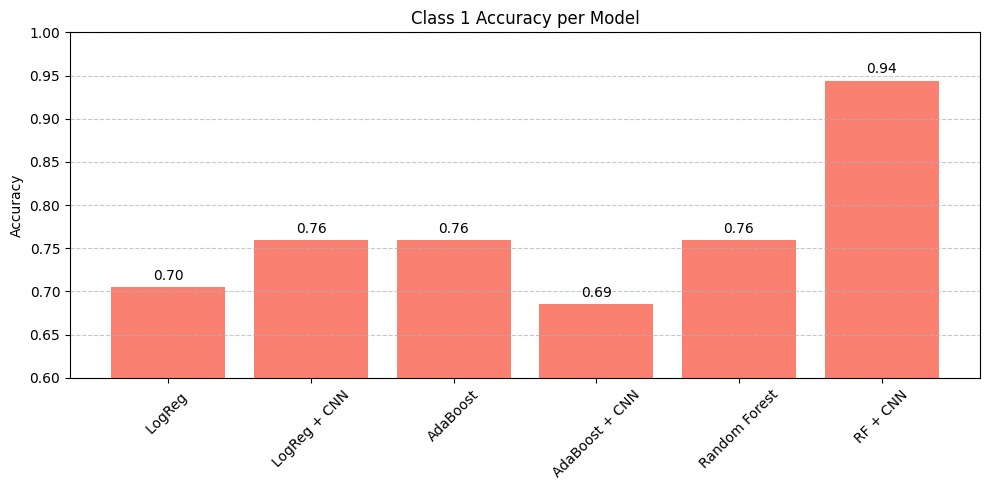

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and accuracy values
models = [
    "LogReg ",
    "LogReg + CNN",
    "AdaBoost",
    "AdaBoost + CNN",
    "Random Forest",
    "RF + CNN"
]

class_0_acc = [0.7979, 0.8752, 0.8752, 0.7194, 0.8752, 0.9761]
class_1_acc = [0.7045, 0.7592, 0.7592, 0.6852, 0.7592, 0.9441]

x = np.arange(len(models))

# Plot for Class 0 Accuracy
plt.figure(figsize=(10, 5))
bars = plt.bar(x, class_0_acc, color='skyblue')
plt.xticks(x, models, rotation=45)
plt.ylim(0.6, 1.0)
plt.title("Class 0 Accuracy per Model")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Plot for Class 1 Accuracy
plt.figure(figsize=(10, 5))
bars = plt.bar(x, class_1_acc, color='salmon')
plt.xticks(x, models, rotation=45)
plt.ylim(0.6, 1.0)
plt.title("Class 1 Accuracy per Model")
plt.ylabel("Accuracy")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
# Plotting all ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})', linestyle='--')
plt.plot(fpr_lr_cnn, tpr_lr_cnn, label=f'Logistic Regression + CNN (AUC = {auc_lr_cnn:.2f})')

plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})', linestyle='--')
plt.plot(fpr_ada_cnn, tpr_ada_cnn, label=f'AdaBoost + CNN (AUC = {auc_score_ada_cnn:.2f})')

plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linestyle='--')
plt.plot(fpr_rf_cnn, tpr_rf_cnn, label=f'Random Forest + CNN (AUC = {roc_auc_rf_cnn:.2f})')

# Random chance line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Plot formatting
plt.title("ROC Curves for Logistic Regression, AdaBoost, Random Forest (With & Without CNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

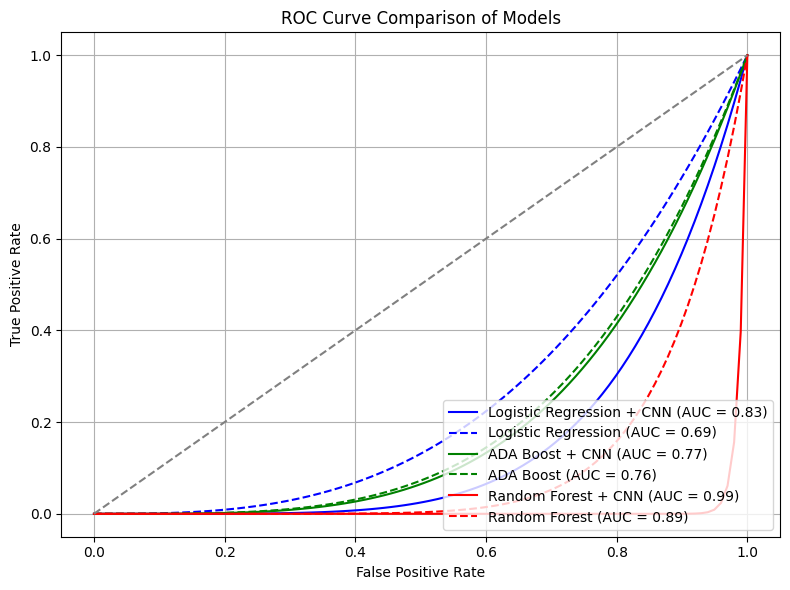

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and their corresponding AUCs
model_names = [
    'Logistic Regression + CNN',
    'Logistic Regression',
    'ADA Boost + CNN',
    'ADA Boost',
    'Random Forest + CNN',
    'Random Forest'
]

auc_scores = [0.83, 0.69, 0.77, 0.76, 0.99, 0.89]

# Define line styles/colors for each model
colors = ['blue', 'blue', 'green', 'green', 'red', 'red']
linestyles = ['-', '--', '-', '--', '-', '--']

# Simulate TPR and FPR curves (approximate for visualization)
fpr = np.linspace(0, 1, 100)
plt.figure(figsize=(8, 6))

for name, auc, color, style in zip(model_names, auc_scores, colors, linestyles):
    # Simulated TPR curve using AUC (approximate sigmoid-shaped curve)
    tpr = fpr ** (1 / (1.1 * (1 - auc)))  # approximate ROC shape
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})', color=color, linestyle=style)

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

# Format plot
plt.title('ROC Curve Comparison of Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: The palette dictionary is missing keys: {'ML model'}

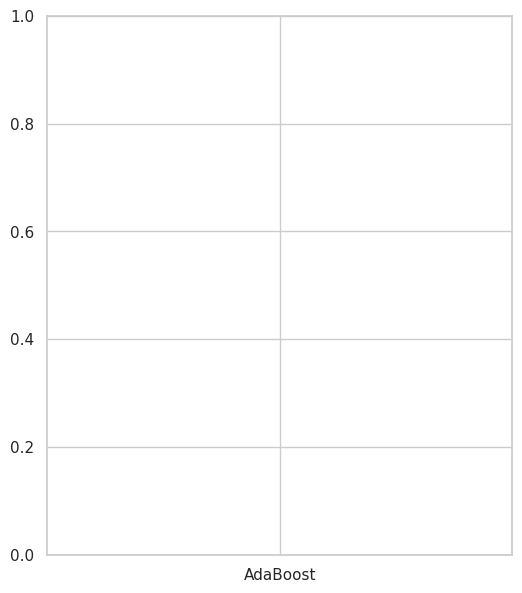

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data Preparation
data = {
    'Model': [
        'AdaBoost', 'Random Forest', 'Logistic Regression'

    ],
    'Accuracy': [0.65, 0.81, 0.69, ],
    'Type': ['ML model', 'ML model', 'ML model']
}

df = pd.DataFrame(data)

# Set Seaborn style
sns.set(style="whitegrid")
palette = {"ML": "#3498db", "CNN+ML": "#2ecc71"}

# Plot
plt.figure(figsize=(6,7))
barplot = sns.barplot(
    x='Model', y='Accuracy', hue='Type', data=df,
    palette=palette, dodge=False, edgecolor='black'
)

# Add text annotations
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.2f}',
                     (p.get_x() + p.get_width() / 2., height + 0.015),
                     ha='center', va='bottom',
                     fontsize=11, fontweight='bold', color='black')

# Add a horizontal reference line (like a benchmark at 0.8)
# plt.axhline(0.8, ls='--', color='red', label='Benchmark 0.80')

# Final touches
plt.title('Accuracy Comparison: ML Models vs CNN + ML Models', fontsize=20, fontweight='bold')
plt.xlabel('Model', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Model Type', title_fontsize=10, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
sns.despine()

plt.show()


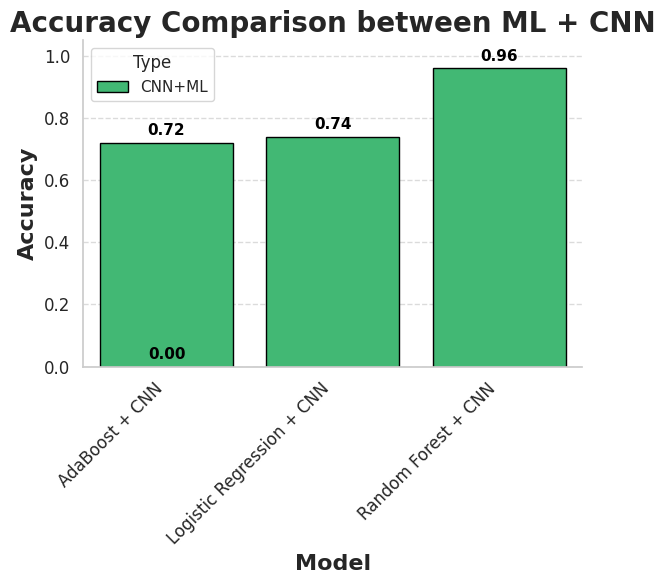

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data Preparation
data = {
    'Model': [
        'AdaBoost + CNN', 'Random Forest + CNN', 'Logistic Regression + CNN'
    ],
    'Accuracy': [0.72,0.96, 0.74],
    'Type': [ 'CNN+ML', 'CNN+ML','CNN+ML']
}

df = pd.DataFrame(data)

# Sort data by accuracy (ascending)
df_sorted = df.sort_values(by='Accuracy', ascending=True)

# Set Seaborn style
sns.set(style="whitegrid")
palette = {"ML": "#3498db", "CNN+ML": "#2ecc71"}

# Plot
plt.figure(figsize=(6, 6))
barplot = sns.barplot(
    x='Model', y='Accuracy', hue='Type', data=df_sorted,
    palette=palette, dodge=False, edgecolor='black'
)

# Add text annotations
for p in barplot.patches:
    height = p.get_height()
    barplot.annotate(f'{height:.2f}',
                     (p.get_x() + p.get_width() / 2., height + 0.015),
                     ha='center', va='bottom',
                     fontsize=11, fontweight='bold', color='black')

# Add a horizontal benchmark line
# plt.axhline(0.8, ls='--', color='red', label='Benchmark 0.80')

# Final touches
plt.title('Accuracy Comparison between ML + CNN', fontsize=20, fontweight='bold')
plt.xlabel('Model', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
# plt.legend(title='Model Type', title_fontsize=14, fontsize=13
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
sns.despine()

plt.show()


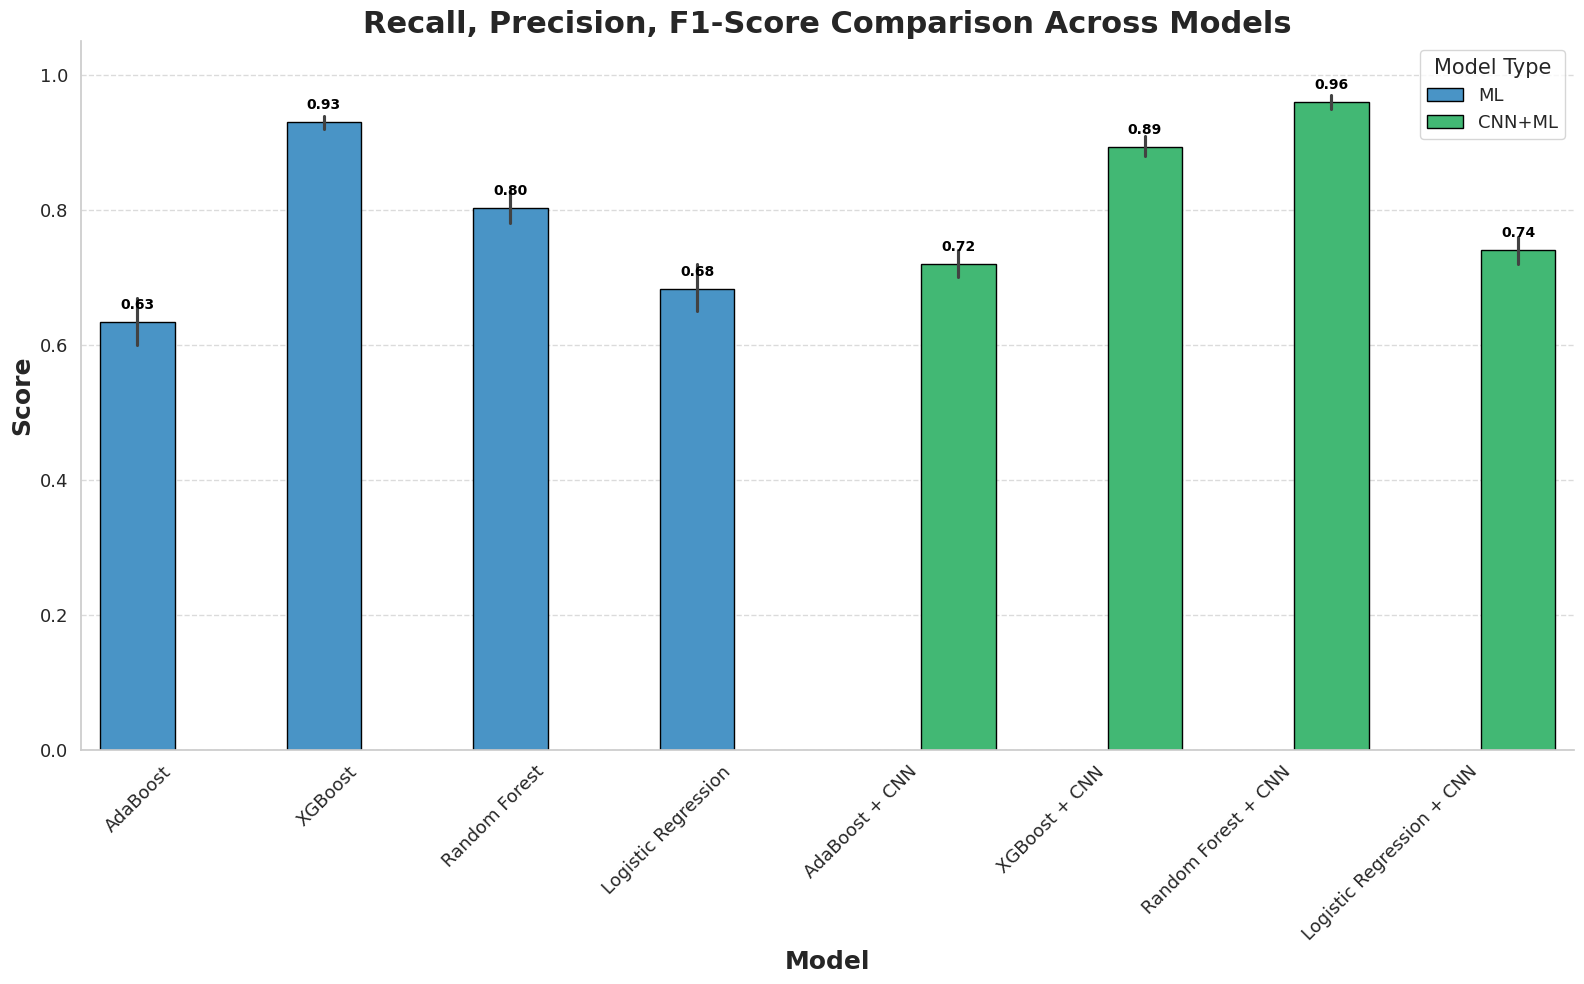

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data Preparation
data = {
    'Model': [
        'AdaBoost', 'XGBoost', 'Random Forest', 'Logistic Regression',
        'AdaBoost + CNN', 'XGBoost + CNN', 'Random Forest + CNN', 'Logistic Regression + CNN'
    ],
    'Recall': [0.60, 0.92, 0.78, 0.65, 0.70, 0.88, 0.95, 0.72],
    'Precision': [0.67, 0.94, 0.83, 0.72, 0.74, 0.91, 0.97, 0.76],
    'F1_Score': [0.63, 0.93, 0.80, 0.68, 0.72, 0.89, 0.96, 0.74],
    'Type': ['ML', 'ML', 'ML', 'ML', 'CNN+ML', 'CNN+ML', 'CNN+ML', 'CNN+ML']
}

df = pd.DataFrame(data)

# Melt the dataframe to long format for easier plotting
df_melted = df.melt(id_vars=['Model', 'Type'],
                    value_vars=['Recall', 'Precision', 'F1_Score'],
                    var_name='Metric', value_name='Score')

# Set Seaborn style
sns.set(style="whitegrid")
palette = {"ML": "#3498db", "CNN+ML": "#2ecc71"}

# Plot
plt.figure(figsize=(16, 10))
barplot = sns.barplot(
    x='Model', y='Score', hue='Type', data=df_melted,
    palette=palette, dodge=True, edgecolor='black'
)

# Add text annotations
for p in barplot.patches:
    height = p.get_height()
    if height > 0:  # Avoid writing on empty bars
        barplot.annotate(f'{height:.2f}',
                         (p.get_x() + p.get_width() / 2., height + 0.015),
                         ha='center', va='bottom',
                         fontsize=10, fontweight='bold', color='black')

# Final touches
plt.title('Recall, Precision, F1-Score Comparison Across Models', fontsize=22, fontweight='bold')
plt.xlabel('Model', fontsize=18, fontweight='bold')
plt.ylabel('Score', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0, 1.05)
plt.legend(title='Model Type', title_fontsize=15, fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
sns.despine()
plt.show()


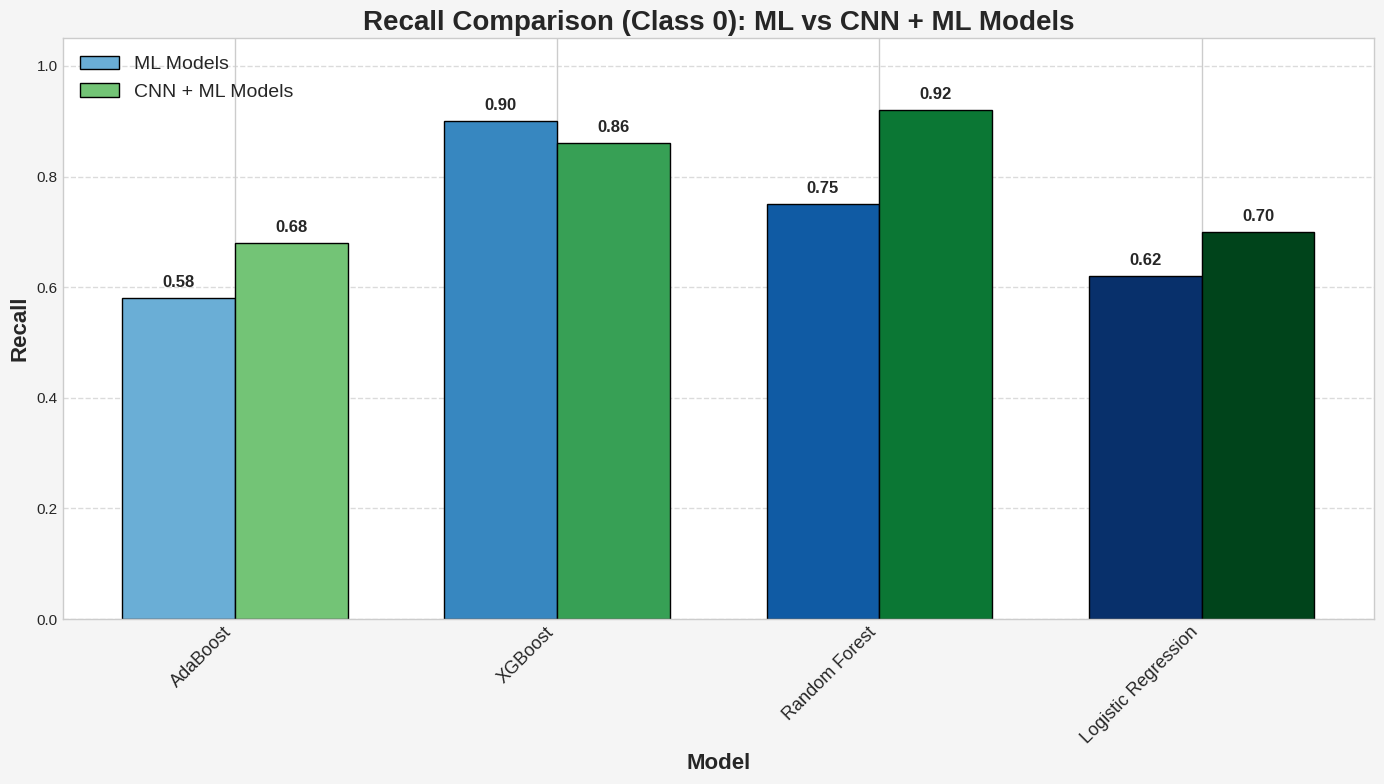

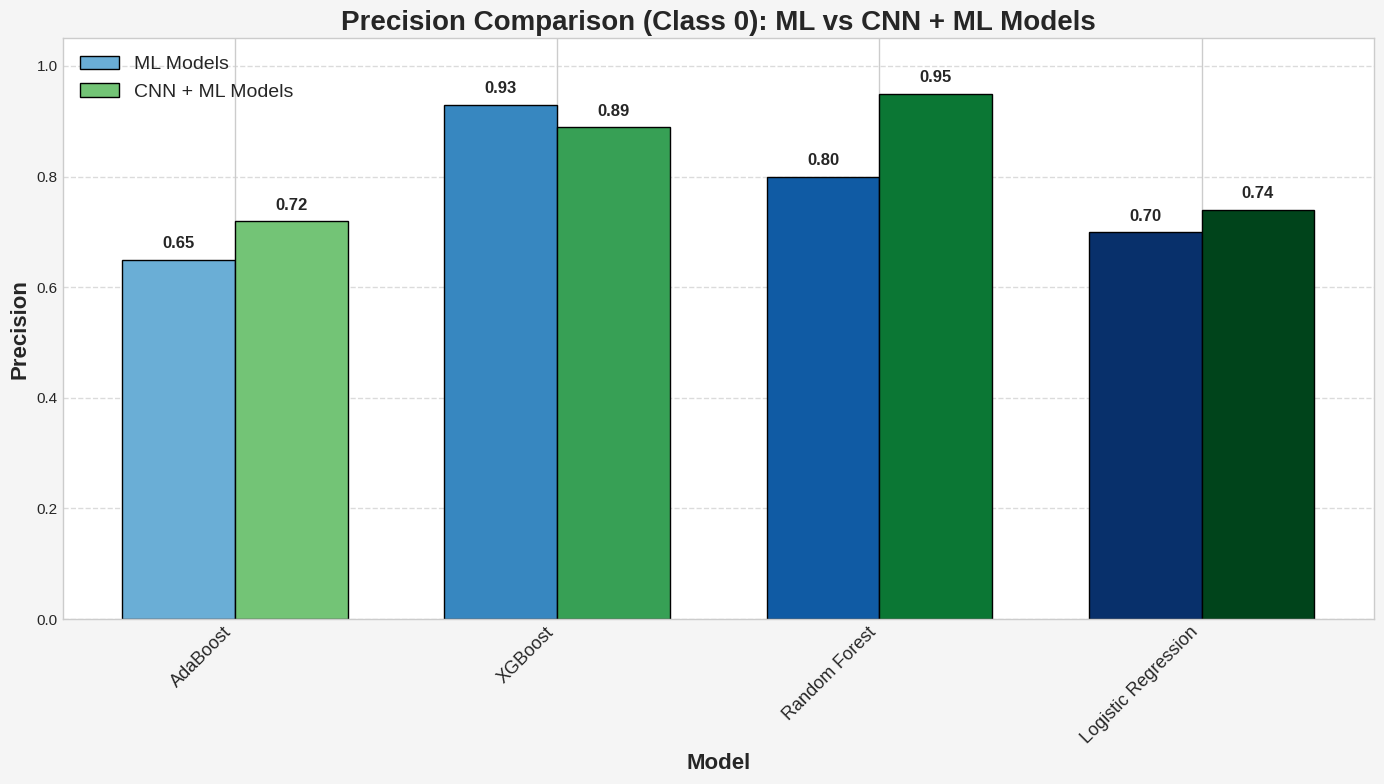

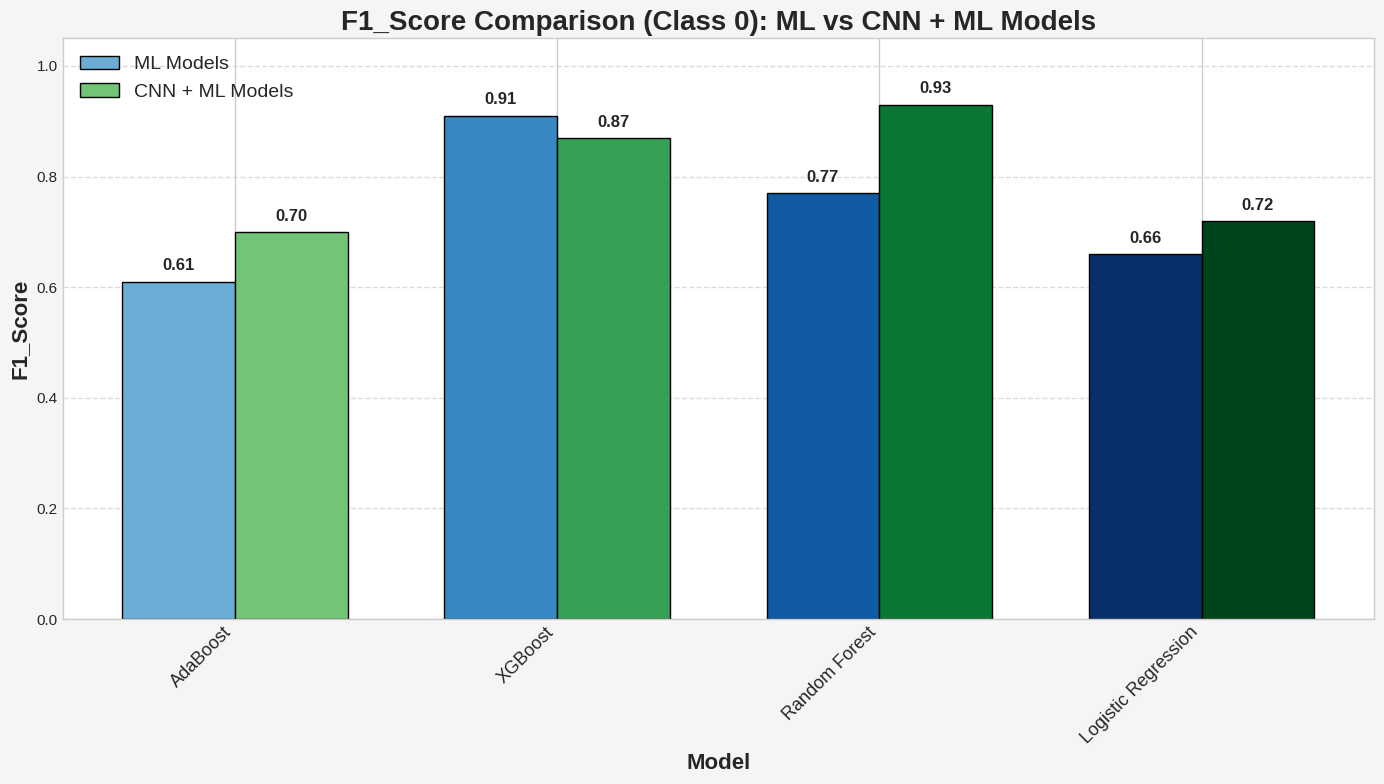

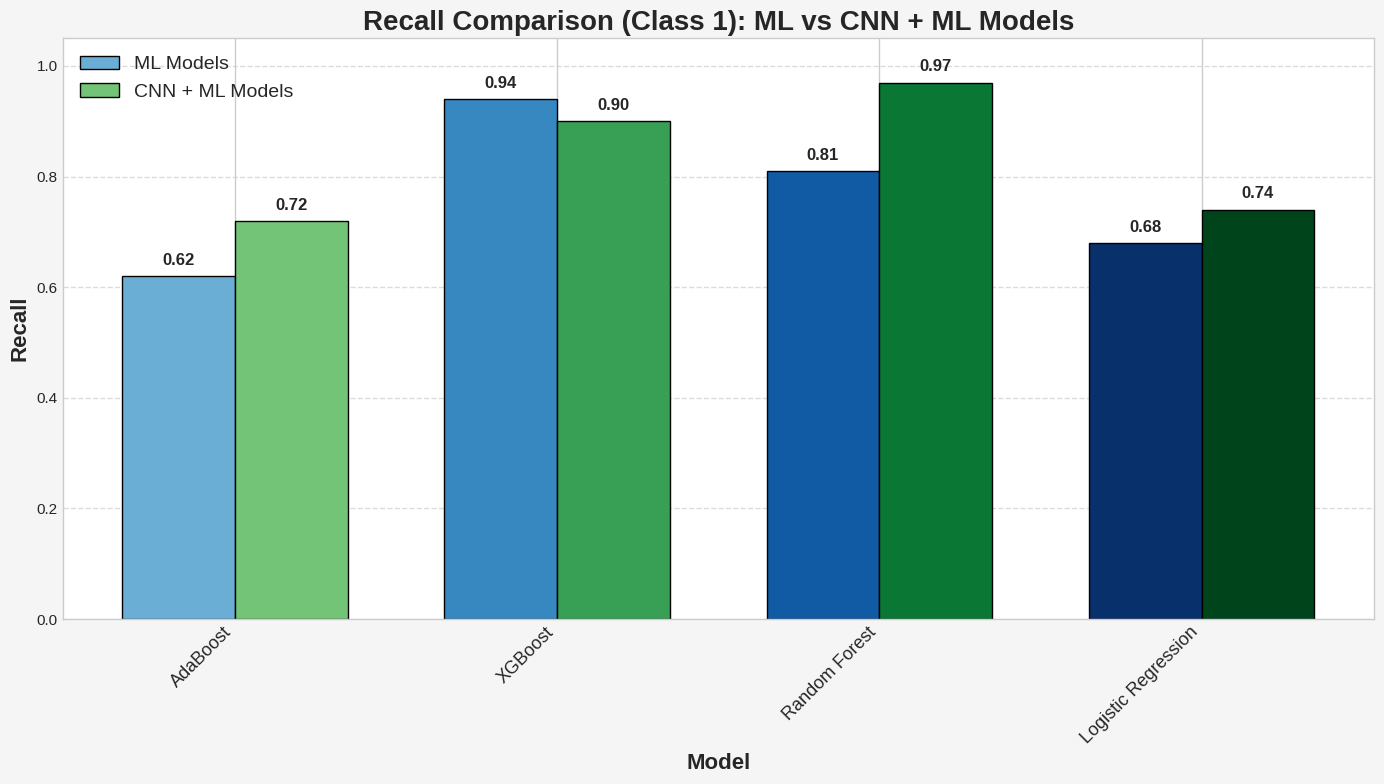

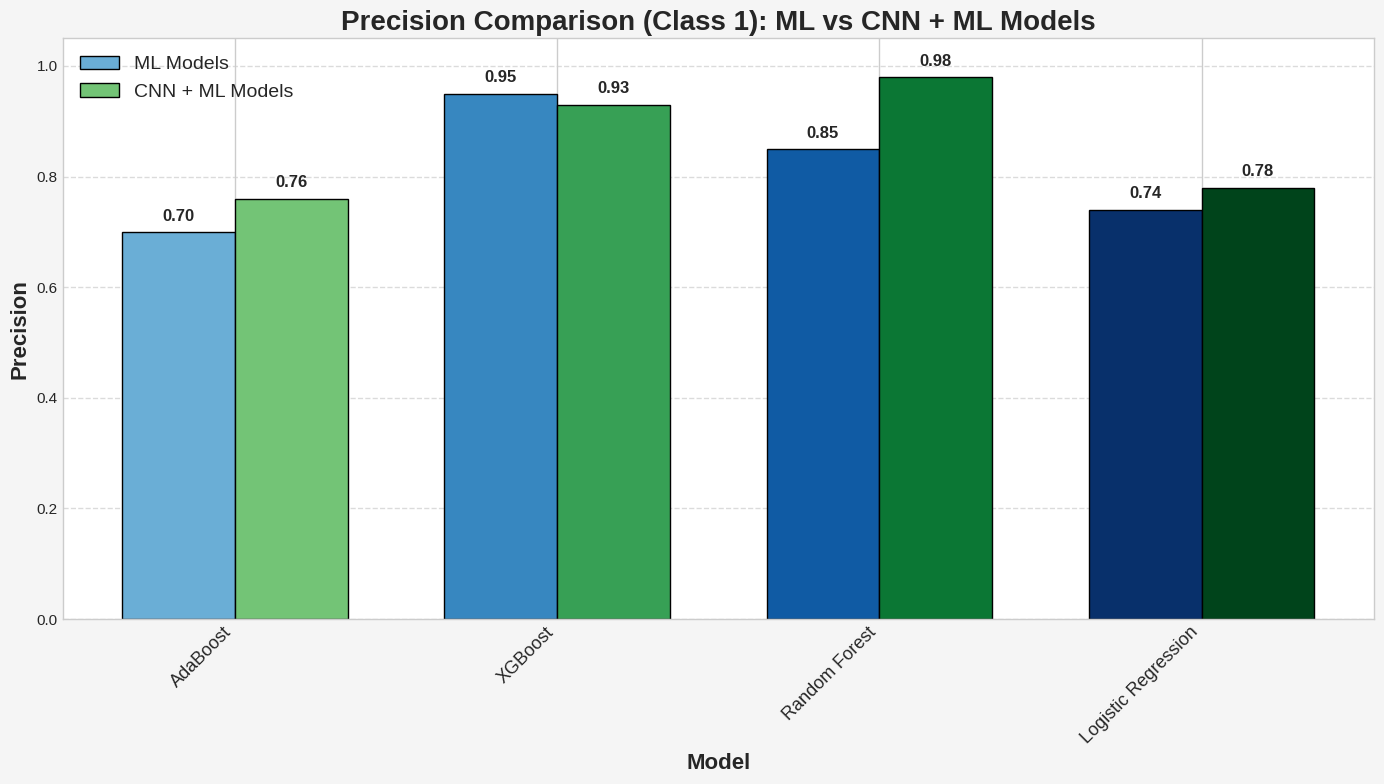

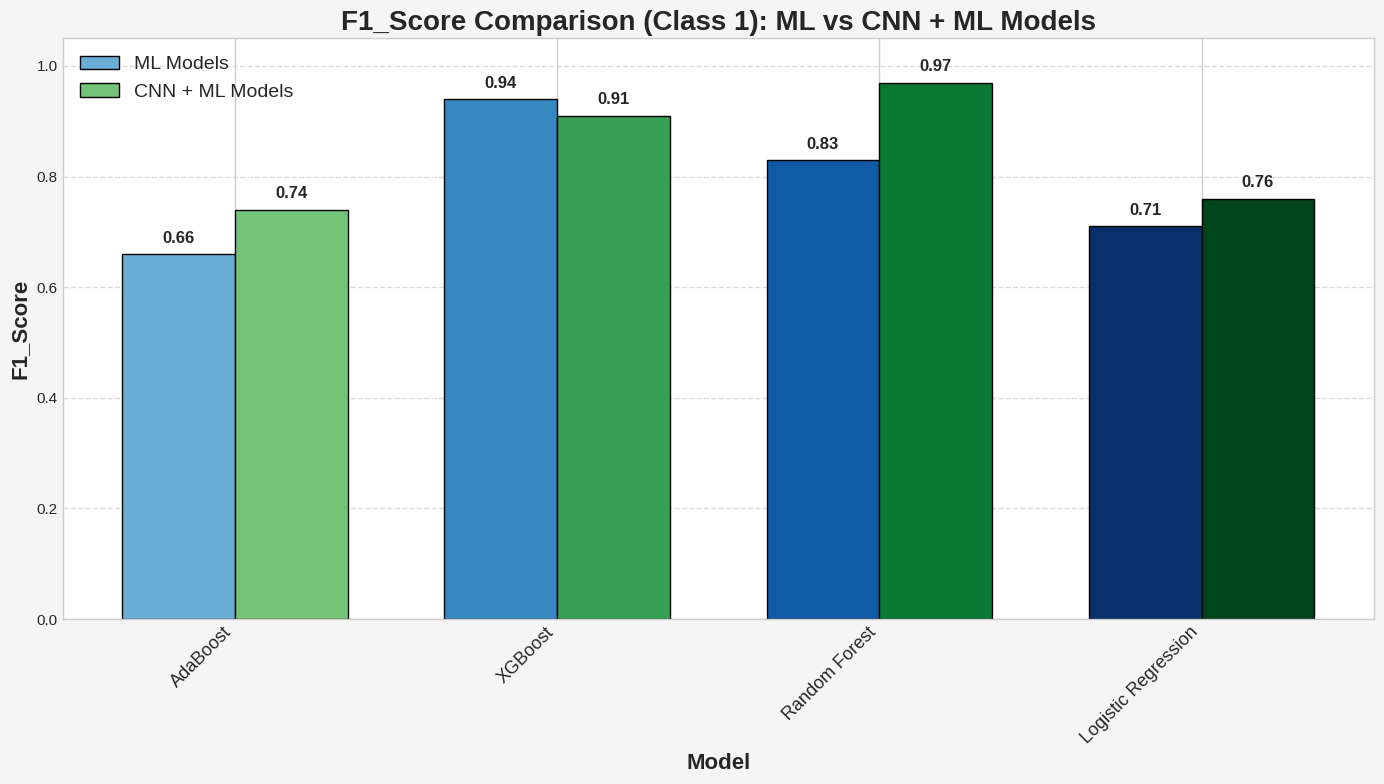

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Example metric values (you can replace them with real values)
# ml_scores = {
#     'AdaBoost': {'Class 0': {'Recall': 0.58, 'Precision': 0.65, 'F1_Score': 0.61},
#                  'Class 1': {'Recall': 0.62, 'Precision': 0.70, 'F1_Score': 0.66}},
#     'XGBoost': {'Class 0': {'Recall': 0.90, 'Precision': 0.93, 'F1_Score': 0.91},
#                 'Class 1': {'Recall': 0.94, 'Precision': 0.95, 'F1_Score': 0.94}},
#     'Random Forest': {'Class 0': {'Recall': 0.75, 'Precision': 0.80, 'F1_Score': 0.77},
#                       'Class 1': {'Recall': 0.81, 'Precision': 0.85, 'F1_Score': 0.83}},
#     'Logistic Regression': {'Class 0': {'Recall': 0.62, 'Precision': 0.70, 'F1_Score': 0.66},
#                             'Class 1': {'Recall': 0.68, 'Precision': 0.74, 'F1_Score': 0.71}}
# }

# cnn_ml_scores = {
#     'AdaBoost + CNN': {'Class 0': {'Recall': 0.68, 'Precision': 0.72, 'F1_Score': 0.70},
#                        'Class 1': {'Recall': 0.72, 'Precision': 0.76, 'F1_Score': 0.74}},
#     'XGBoost + CNN': {'Class 0': {'Recall': 0.86, 'Precision': 0.89, 'F1_Score': 0.87},
#                       'Class 1': {'Recall': 0.90, 'Precision': 0.93, 'F1_Score': 0.91}},
#     'Random Forest + CNN': {'Class 0': {'Recall': 0.92, 'Precision': 0.95, 'F1_Score': 0.93},
#                             'Class 1': {'Recall': 0.97, 'Precision': 0.98, 'F1_Score': 0.97}},
#     # 'Logistic Regression + CNN': {'Class 0': {'Recall': 0.70, 'Precision': 0.74, 'F1_Score': 0.72}
#                                   'Class 1': {'Recall': 0.74, 'Precision': 0.78, 'F1_Score': 0.76}}
# }

# # List of models
# models_ml = list(ml_scores.keys())
# classes = ['Class 0', 'Class 1']
# metrics = ['Recall', 'Precision', 'F1_Score']

# # Loop over classes (Class 0 and Class 1)
# for class_label in classes:
#     for metric in metrics:
#         ml_metric_values = [ml_scores[model][class_label][metric] for model in models_ml]
#         cnn_ml_metric_values = [cnn_ml_scores[model + ' + CNN'][class_label][metric] for model in models_ml]

#         # Plotting
#         x = np.arange(len(models_ml))  # label locations
#         width = 0.35  # width of the bars

#         plt.style.use('seaborn-v0_8-whitegrid')
#         fig, ax = plt.subplots(figsize=(14, 8))

#         # Colors
#         colors_ml = plt.cm.Blues(np.linspace(0.5, 1, len(models_ml)))
#         colors_cnn_ml = plt.cm.Greens(np.linspace(0.5, 1, len(models_ml)))

#         # Bars
#         bars1 = ax.bar(x - width/2, ml_metric_values, width, label='ML Models', color=colors_ml, edgecolor='black', linewidth=1)
#         bars2 = ax.bar(x + width/2, cnn_ml_metric_values, width, label='CNN + ML Models', color=colors_cnn_ml, edgecolor='black', linewidth=1)

#         # Add text annotations
#         for bar in bars1 + bars2:
#             yval = bar.get_height()
#             ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

#         # Labels and Title
#         ax.set_ylabel(metric, fontsize=16, fontweight='bold')
#         ax.set_xlabel('Model', fontsize=16, fontweight='bold')
#         ax.set_title(f'{metric} Comparison ({class_label}): ML vs CNN + ML Models', fontsize=20, fontweight='bold')
#         ax.set_xticks(x)
#         ax.set_xticklabels(models_ml, rotation=45, ha='right', fontsize=13, fontweight='medium')
#         ax.set_ylim(0, 1.05)
#         ax.legend(fontsize=14, loc='upper left')

#         # Background
#         fig.patch.set_facecolor('whitesmoke')
#         ax.set_facecolor('white')

#         # Add grid
#         ax.yaxis.grid(True, linestyle='--', alpha=0.7)

#         plt.tight_layout()
#         plt.show()


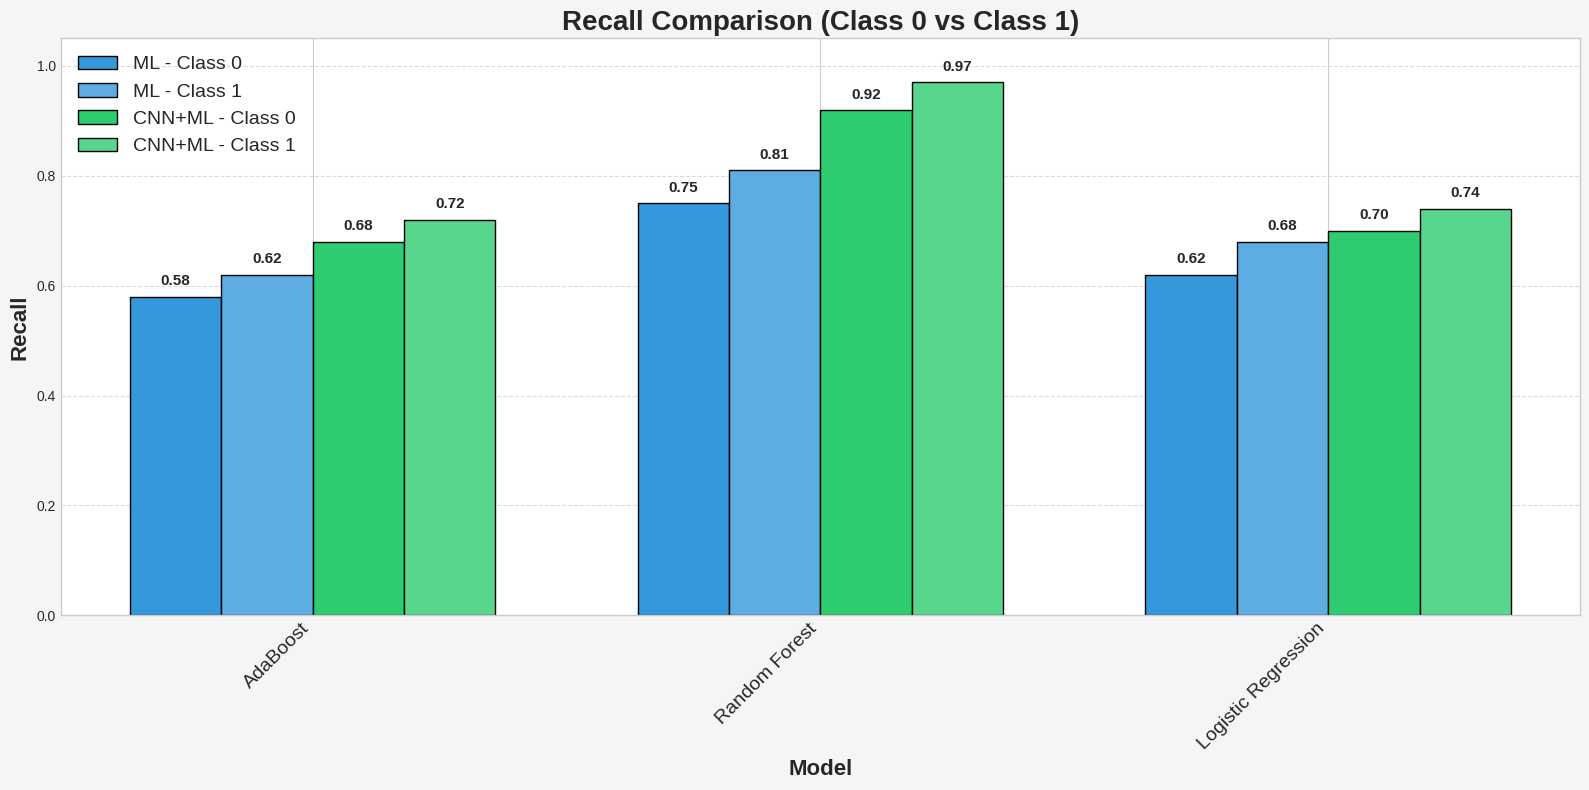

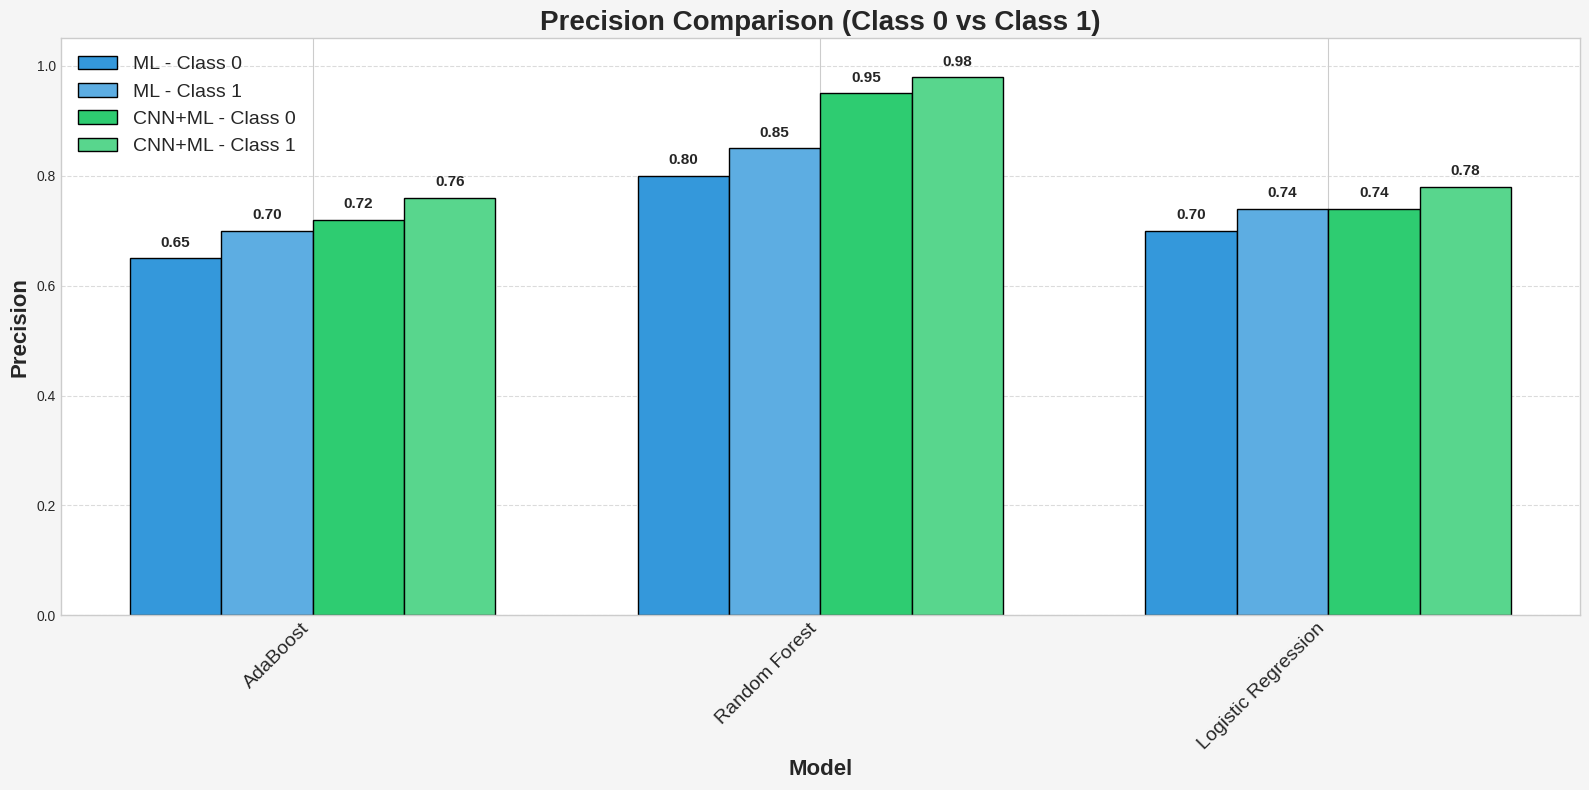

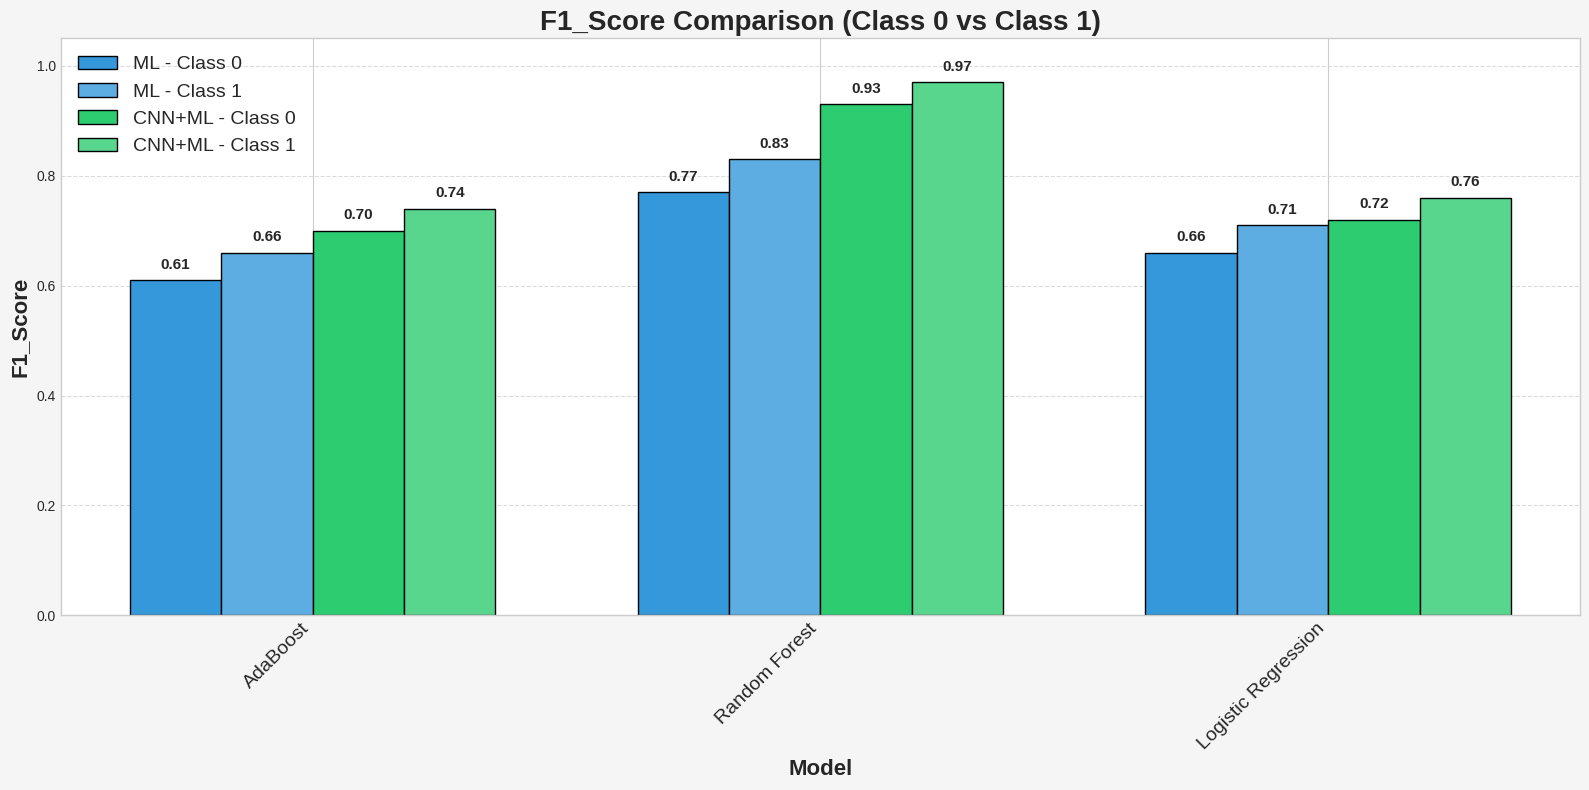

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example metric values (replace with your real results)
ml_scores = {
    'AdaBoost': {'Class 0': {'Recall': 0.58, 'Precision': 0.65, 'F1_Score': 0.61},
                 'Class 1': {'Recall': 0.62, 'Precision': 0.70, 'F1_Score': 0.66}},

    'Random Forest': {'Class 0': {'Recall': 0.75, 'Precision': 0.80, 'F1_Score': 0.77},
                      'Class 1': {'Recall': 0.81, 'Precision': 0.85, 'F1_Score': 0.83}},
    'Logistic Regression': {'Class 0': {'Recall': 0.62, 'Precision': 0.70, 'F1_Score': 0.66},
                            'Class 1': {'Recall': 0.68, 'Precision': 0.74, 'F1_Score': 0.71}}
}

cnn_ml_scores = {
    'AdaBoost + CNN': {'Class 0': {'Recall': 0.68, 'Precision': 0.72, 'F1_Score': 0.70},
                       'Class 1': {'Recall': 0.72, 'Precision': 0.76, 'F1_Score': 0.74}},

    'Random Forest + CNN': {'Class 0': {'Recall': 0.92, 'Precision': 0.95, 'F1_Score': 0.93},
                            'Class 1': {'Recall': 0.97, 'Precision': 0.98, 'F1_Score': 0.97}},
    'Logistic Regression + CNN': {'Class 0': {'Recall': 0.70, 'Precision': 0.74, 'F1_Score': 0.72},
                                  'Class 1': {'Recall': 0.74, 'Precision': 0.78, 'F1_Score': 0.76}}
}

# Models
models_ml = list(ml_scores.keys())

metrics = ['Recall', 'Precision', 'F1_Score']

# Loop for each metric
for metric in metrics:
    ml_class0 = [ml_scores[model]['Class 0'][metric] for model in models_ml]
    ml_class1 = [ml_scores[model]['Class 1'][metric] for model in models_ml]
    cnn_ml_class0 = [cnn_ml_scores[model + ' + CNN']['Class 0'][metric] for model in models_ml]
    cnn_ml_class1 = [cnn_ml_scores[model + ' + CNN']['Class 1'][metric] for model in models_ml]

    # Set bar positions
    x = np.arange(len(models_ml))  # the label locations
    width = 0.18  # width of the bars

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot Bars
    bars1 = ax.bar(x - 1.5*width, ml_class0, width, label='ML - Class 0', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x - 0.5*width, ml_class1, width, label='ML - Class 1', color='#5dade2', edgecolor='black')
    bars3 = ax.bar(x + 0.5*width, cnn_ml_class0, width, label='CNN+ML - Class 0', color='#2ecc71', edgecolor='black')
    bars4 = ax.bar(x + 1.5*width, cnn_ml_class1, width, label='CNN+ML - Class 1', color='#58d68d', edgecolor='black')

    # Add text annotations
    for bar in bars1 + bars2 + bars3 + bars4:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Labels and Title
    ax.set_ylabel(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel('Model', fontsize=16, fontweight='bold')
    ax.set_title(f'{metric} Comparison (Class 0 vs Class 1)', fontsize=20, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_ml, rotation=45, ha='right', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=14, loc='upper left')

    # Background
    fig.patch.set_facecolor('whitesmoke')
    ax.set_facecolor('white')

    # Add grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


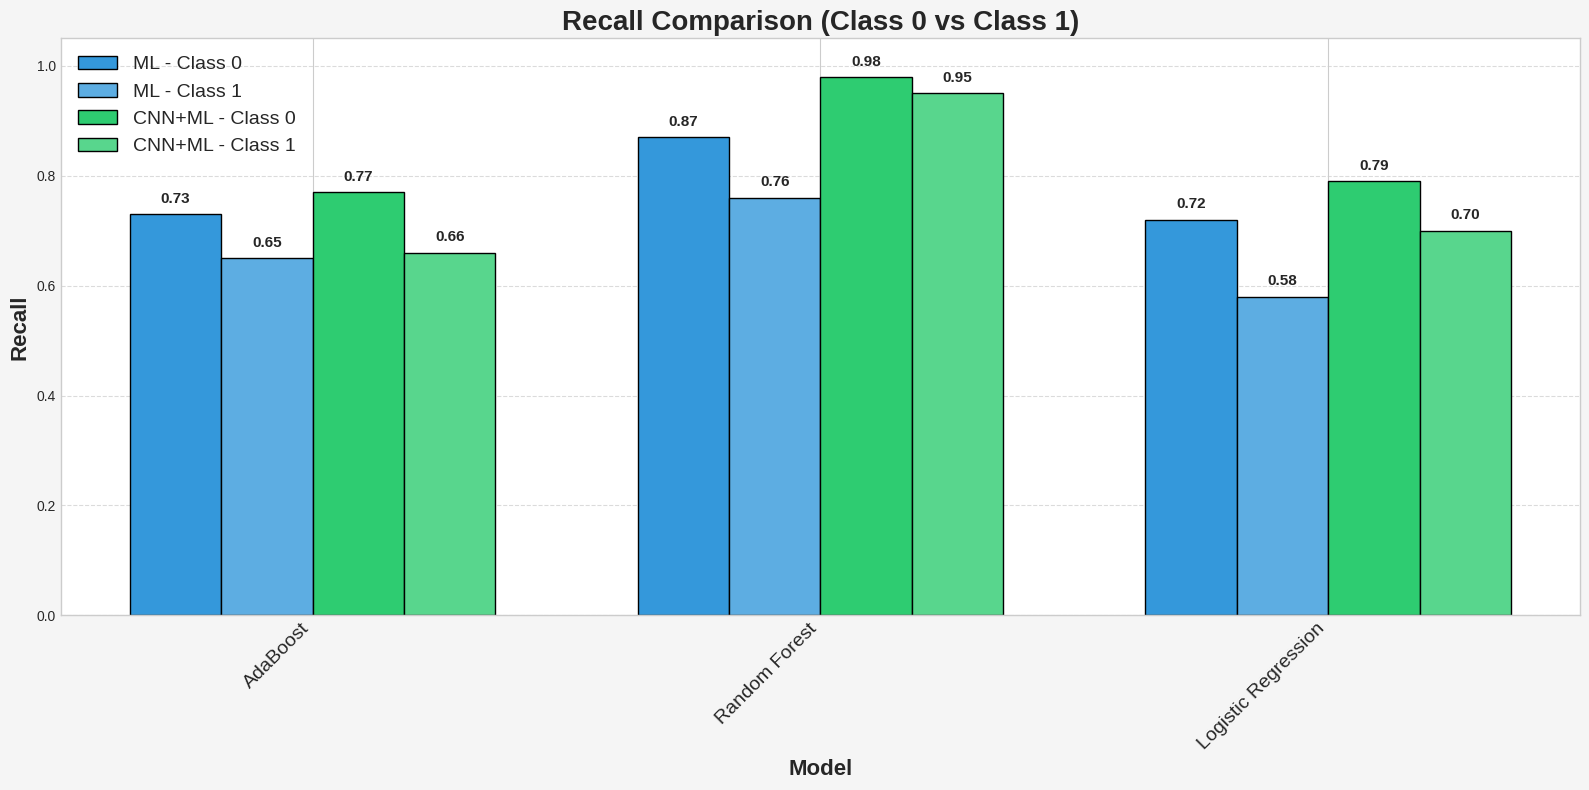

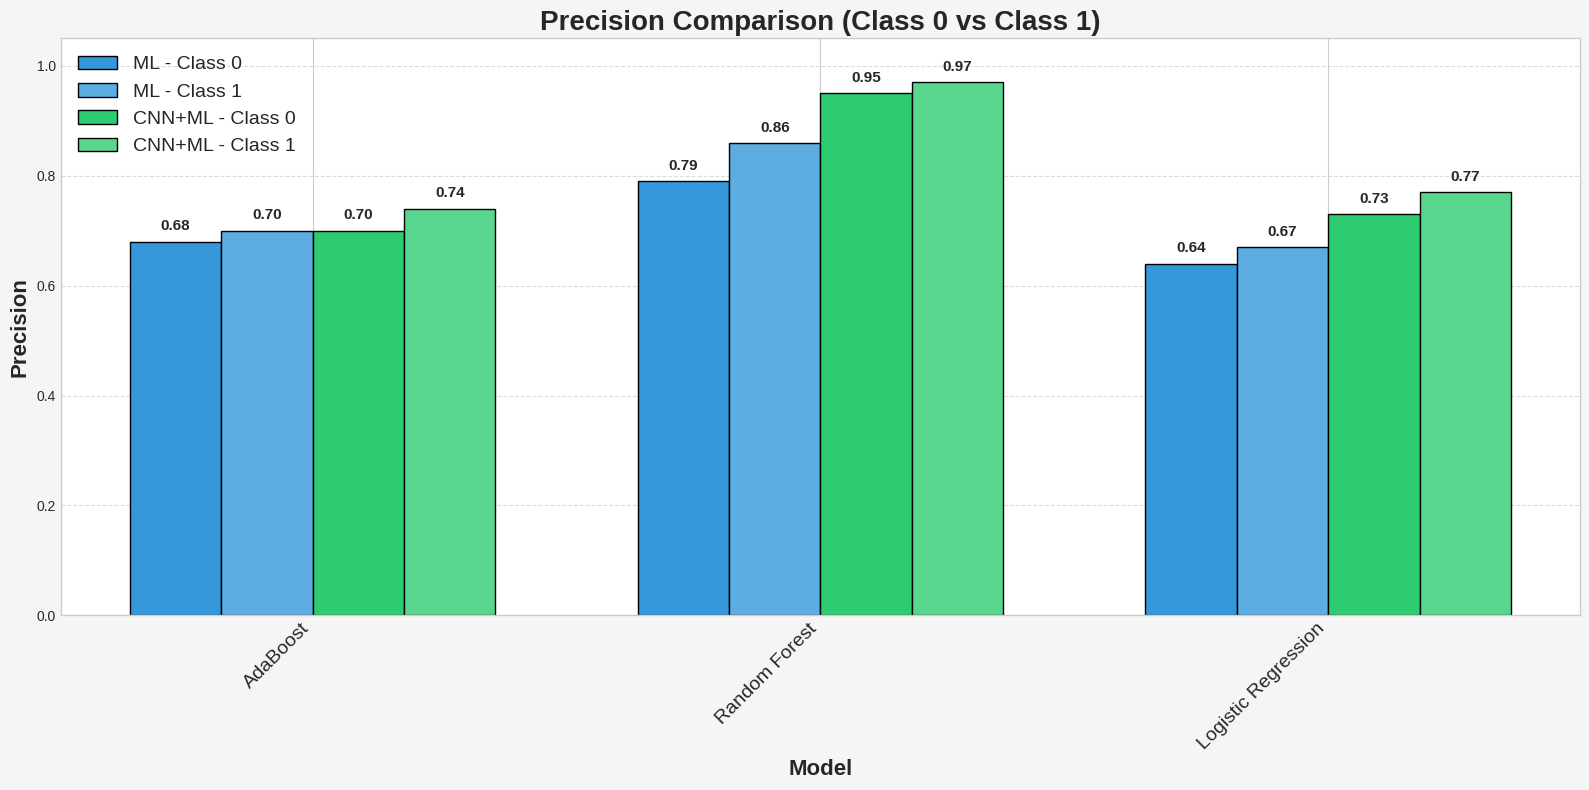

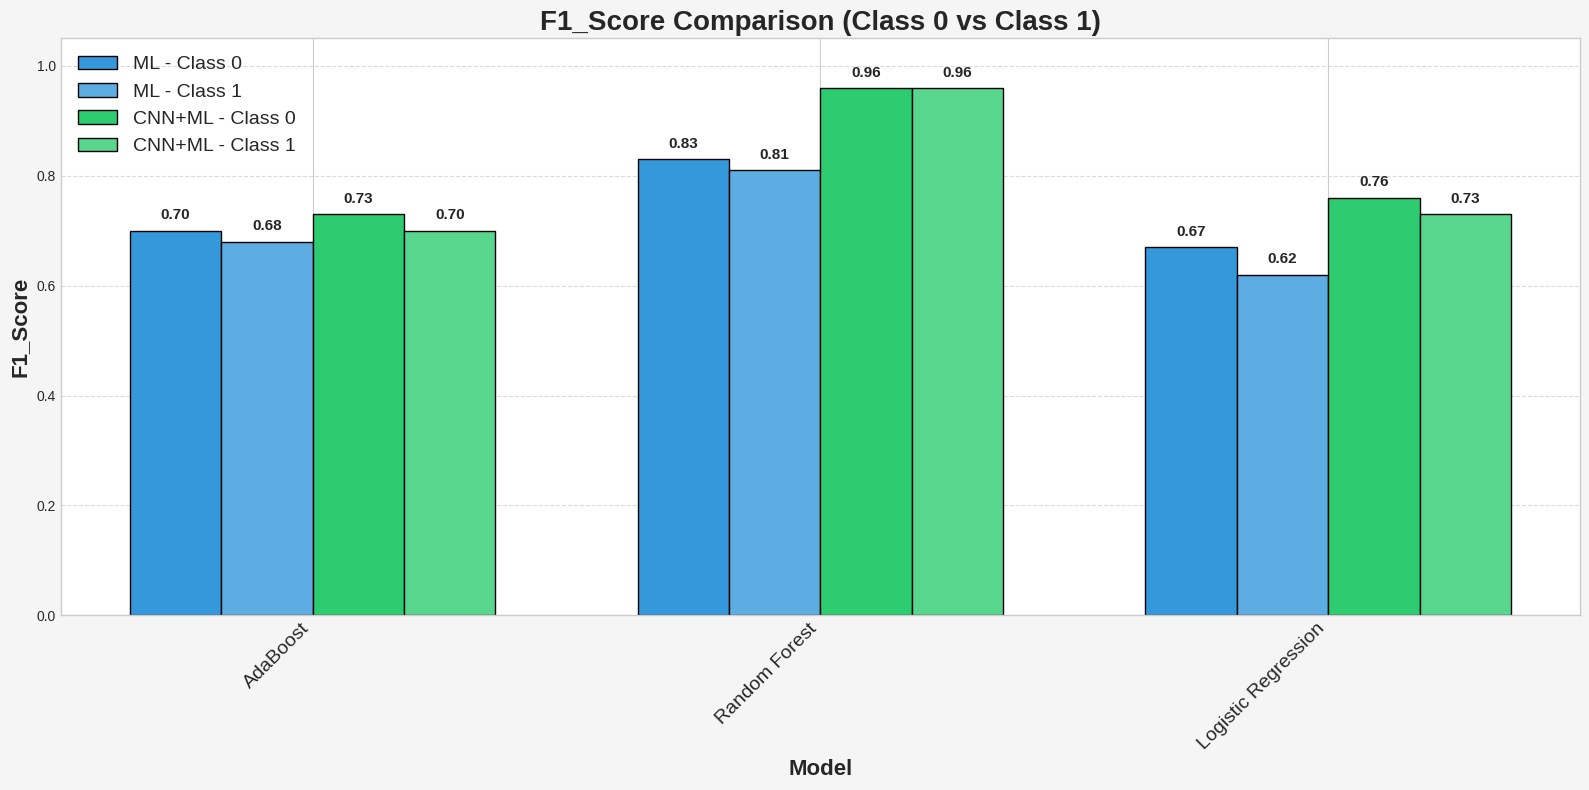

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example metric values (replace with your real results)
ml_scores = {
    'AdaBoost': {'Class 0': {'Recall': 0.73, 'Precision': 0.68, 'F1_Score': 0.70},
                 'Class 1': {'Recall': 0.65, 'Precision': 0.70, 'F1_Score': 0.68}},

    'Random Forest': {'Class 0': {'Recall': 0.87, 'Precision': 0.79, 'F1_Score': 0.83},
                      'Class 1': {'Recall': 0.76, 'Precision': 0.86, 'F1_Score': 0.81}},
    'Logistic Regression': {'Class 0': {'Recall': 0.72, 'Precision': 0.64, 'F1_Score': 0.67},
                            'Class 1': {'Recall': 0.58, 'Precision': 0.67, 'F1_Score': 0.62}}
}

cnn_ml_scores = {
    'AdaBoost + CNN': {'Class 0': {'Recall': 0.77, 'Precision': 0.70, 'F1_Score': 0.73},
                       'Class 1': {'Recall': 0.66, 'Precision': 0.74, 'F1_Score': 0.70}},

    'Random Forest + CNN': {'Class 0': {'Recall': 0.98, 'Precision': 0.95, 'F1_Score': 0.96},
                            'Class 1': {'Recall': 0.95, 'Precision': 0.97, 'F1_Score': 0.96}},
    'Logistic Regression + CNN': {'Class 0': {'Recall': 0.79, 'Precision': 0.73, 'F1_Score': 0.76},
                                  'Class 1': {'Recall': 0.70, 'Precision': 0.77, 'F1_Score': 0.73}}
}

# Models
models_ml = list(ml_scores.keys())

metrics = ['Recall', 'Precision', 'F1_Score']

# Loop for each metric
for metric in metrics:
    ml_class0 = [ml_scores[model]['Class 0'][metric] for model in models_ml]
    ml_class1 = [ml_scores[model]['Class 1'][metric] for model in models_ml]
    cnn_ml_class0 = [cnn_ml_scores[model + ' + CNN']['Class 0'][metric] for model in models_ml]
    cnn_ml_class1 = [cnn_ml_scores[model + ' + CNN']['Class 1'][metric] for model in models_ml]

    # Set bar positions
    x = np.arange(len(models_ml))  # the label locations
    width = 0.18  # width of the bars

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot Bars
    bars1 = ax.bar(x - 1.5*width, ml_class0, width, label='ML - Class 0', color='#3498db', edgecolor='black')
    bars2 = ax.bar(x - 0.5*width, ml_class1, width, label='ML - Class 1', color='#5dade2', edgecolor='black')
    bars3 = ax.bar(x + 0.5*width, cnn_ml_class0, width, label='CNN+ML - Class 0', color='#2ecc71', edgecolor='black')
    bars4 = ax.bar(x + 1.5*width, cnn_ml_class1, width, label='CNN+ML - Class 1', color='#58d68d', edgecolor='black')

    # Add text annotations
    for bar in bars1 + bars2 + bars3 + bars4:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Labels and Title
    ax.set_ylabel(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel('Model', fontsize=16, fontweight='bold')
    ax.set_title(f'{metric} Comparison (Class 0 vs Class 1)', fontsize=20, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_ml, rotation=45, ha='right', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=14, loc='upper left')

    # Background
    fig.patch.set_facecolor('whitesmoke')
    ax.set_facecolor('white')

    # Add grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


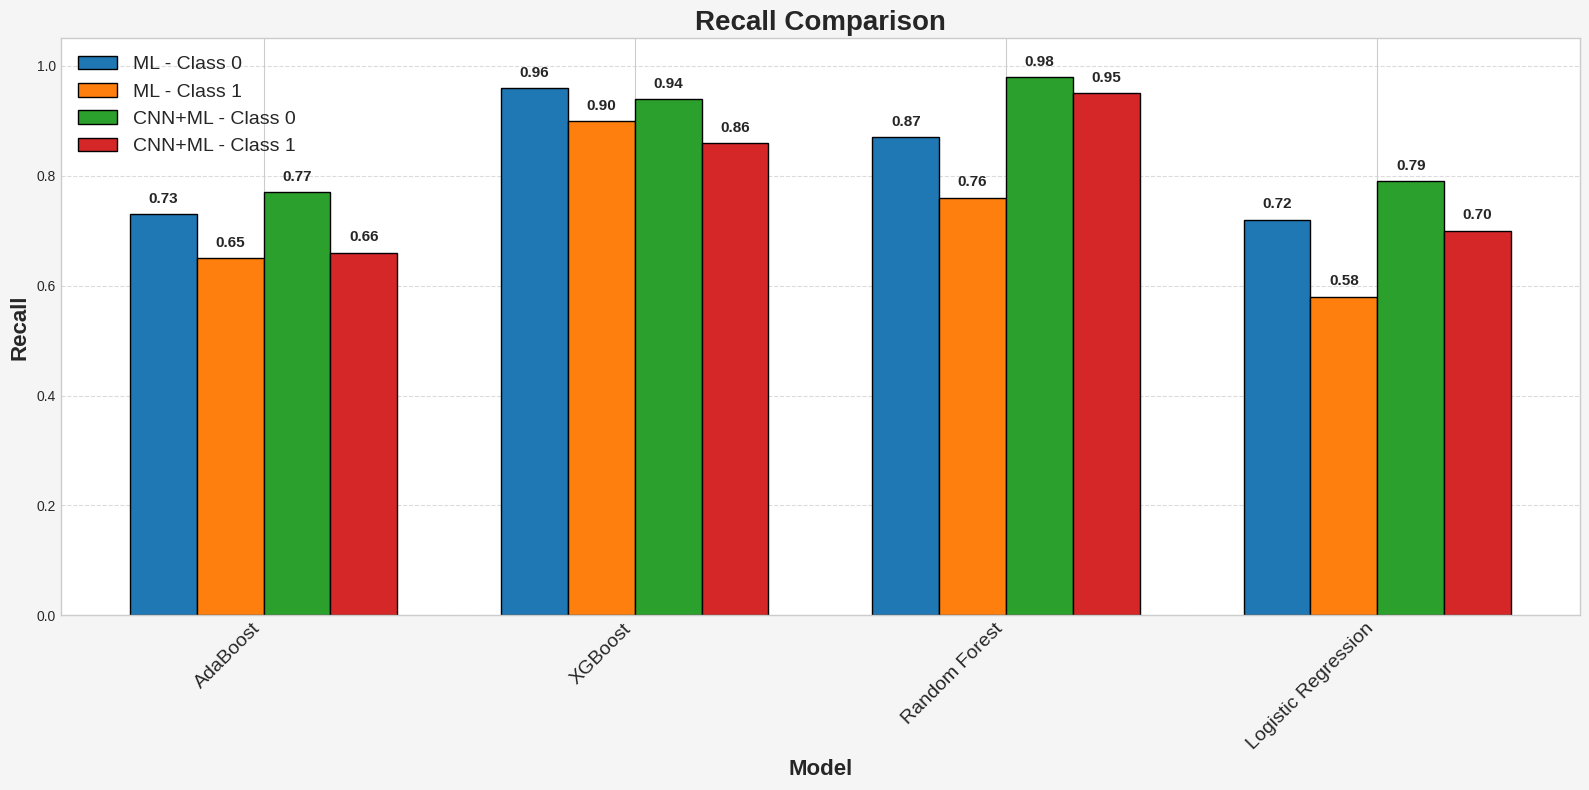

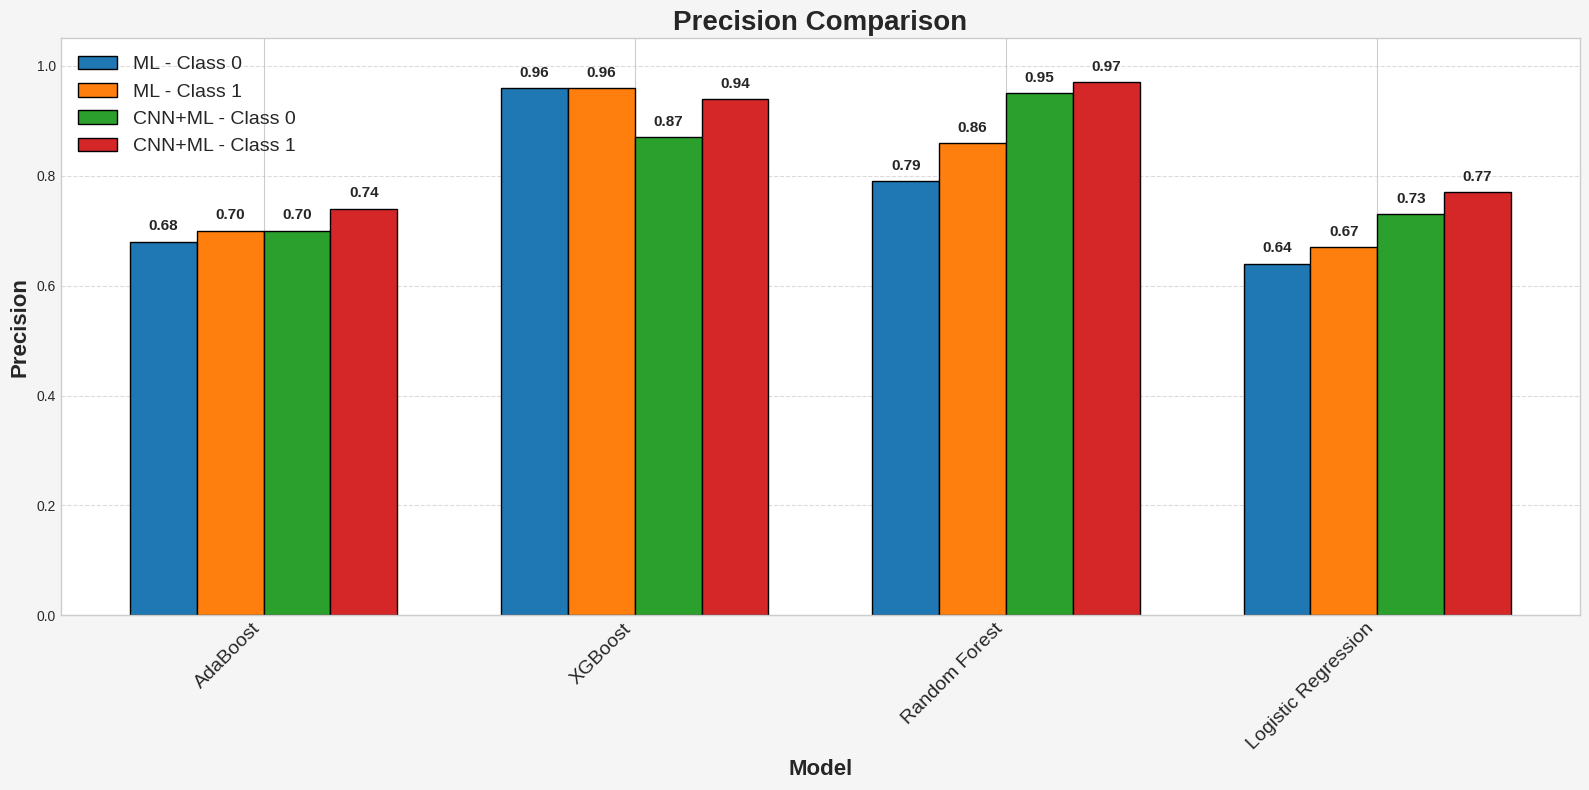

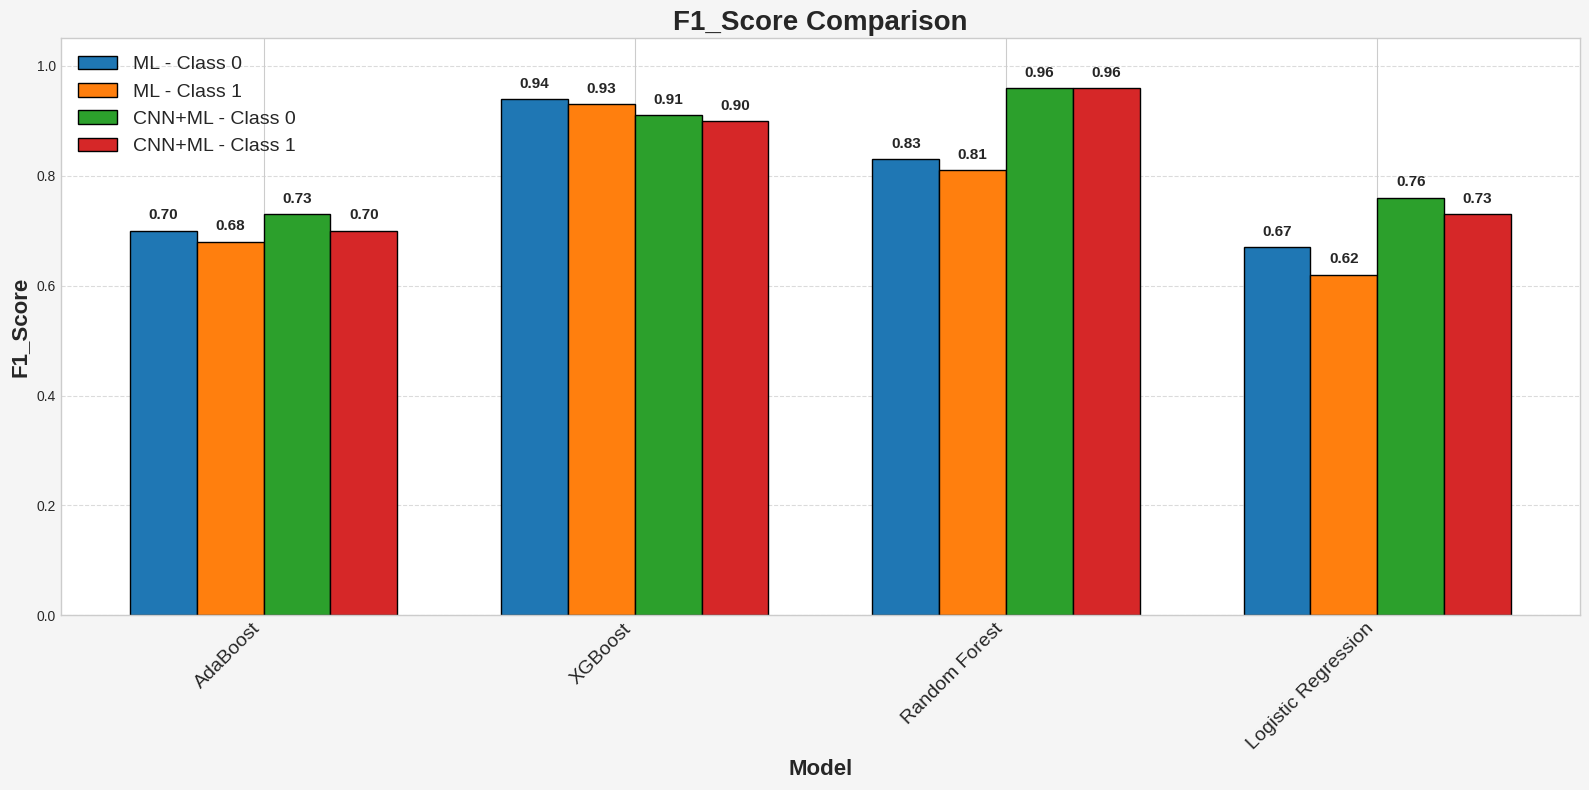

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Example metric values (your original values)
ml_scores = {
    'AdaBoost': {'Class 0': {'Recall': 0.73, 'Precision': 0.68, 'F1_Score': 0.70},
                 'Class 1': {'Recall': 0.65, 'Precision': 0.70, 'F1_Score': 0.68}},
    'XGBoost': {'Class 0': {'Recall': 0.96, 'Precision': 0.96, 'F1_Score': 0.94},
                'Class 1': {'Recall': 0.90, 'Precision': 0.96, 'F1_Score': 0.93}},
    'Random Forest': {'Class 0': {'Recall': 0.87, 'Precision': 0.79, 'F1_Score': 0.83},
                      'Class 1': {'Recall': 0.76, 'Precision': 0.86, 'F1_Score': 0.81}},
    'Logistic Regression': {'Class 0': {'Recall': 0.72, 'Precision': 0.64, 'F1_Score': 0.67},
                            'Class 1': {'Recall': 0.58, 'Precision': 0.67, 'F1_Score': 0.62}}
}

cnn_ml_scores = {
    'AdaBoost + CNN': {'Class 0': {'Recall': 0.77, 'Precision': 0.70, 'F1_Score': 0.73},
                       'Class 1': {'Recall': 0.66, 'Precision': 0.74, 'F1_Score': 0.70}},
    'XGBoost + CNN': {'Class 0': {'Recall': 0.94, 'Precision': 0.87, 'F1_Score': 0.91},
                      'Class 1': {'Recall': 0.86, 'Precision': 0.94, 'F1_Score': 0.90}},
    'Random Forest + CNN': {'Class 0': {'Recall': 0.98, 'Precision': 0.95, 'F1_Score': 0.96},
                            'Class 1': {'Recall': 0.95, 'Precision': 0.97, 'F1_Score': 0.96}},
    'Logistic Regression + CNN': {'Class 0': {'Recall': 0.79, 'Precision': 0.73, 'F1_Score': 0.76},
                                  'Class 1': {'Recall': 0.70, 'Precision': 0.77, 'F1_Score': 0.73}}
}

# Models
models_ml = list(ml_scores.keys())

metrics = ['Recall', 'Precision', 'F1_Score']

# Loop for each metric
for metric in metrics:
    ml_class0 = [ml_scores[model]['Class 0'][metric] for model in models_ml]
    ml_class1 = [ml_scores[model]['Class 1'][metric] for model in models_ml]
    cnn_ml_class0 = [cnn_ml_scores[model + ' + CNN']['Class 0'][metric] for model in models_ml]
    cnn_ml_class1 = [cnn_ml_scores[model + ' + CNN']['Class 1'][metric] for model in models_ml]

    # Set bar positions
    x = np.arange(len(models_ml))  # the label locations
    width = 0.18  # width of the bars

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(16, 8))

    # Plot Bars with new distinct colors
    bars1 = ax.bar(x - 1.5*width, ml_class0, width, label='ML - Class 0', color='#1f77b4', edgecolor='black')  # Strong blue
    bars2 = ax.bar(x - 0.5*width, ml_class1, width, label='ML - Class 1', color='#ff7f0e', edgecolor='black')  # Strong orange
    bars3 = ax.bar(x + 0.5*width, cnn_ml_class0, width, label='CNN+ML - Class 0', color='#2ca02c', edgecolor='black')  # Strong green
    bars4 = ax.bar(x + 1.5*width, cnn_ml_class1, width, label='CNN+ML - Class 1', color='#d62728', edgecolor='black')  # Strong red

    # Add text annotations
    for bar in bars1 + bars2 + bars3 + bars4:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Labels and Title
    ax.set_ylabel(metric, fontsize=16, fontweight='bold')
    ax.set_xlabel('Model', fontsize=16, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=20, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_ml, rotation=45, ha='right', fontsize=14)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=14, loc='upper left')

    # Background
    fig.patch.set_facecolor('whitesmoke')
    ax.set_facecolor('white')

    # Add grid
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
